In [1]:
# =============================================================================
# ML Time-Series Project: Russia Military Equipment Losses Forecasting
# =============================================================================
# Phase 1: Data Preprocessing & Feature Engineering
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# =============================================================================
# 1.1 Load Data
# =============================================================================

df = pd.read_parquet("russia_losses_equipment_final.parquet")
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
df.head(10)

Dataset shape: (1312, 20)
Date range: 2022-02-25 to 2025-09-28


,day,date,aircraft,helicopter,tank,APC,field artillery,MRL,military auto,fuel tank,drone,naval ship,anti-aircraft warfare,special equipment,mobile SRBM system,greatest losses direction,vehicles and fuel tanks,cruise missiles,submarines,personnel
0,2,2022-02-25,10.0,7.0,80.0,516.0,49.0,4.0,100.0,60.0,0.0,2.0,0.0,10.0,2.0,None,1796.0,84.0,0.0,2800.0
1,3,2022-02-26,17.0,19.0,66.0,190.0,0.0,0.0,30.0,0.0,2.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,1500.0
2,4,2022-02-27,0.0,0.0,4.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,0.0,0.0,0.0,200.0
3,5,2022-02-28,2.0,3.0,0.0,110.0,24.0,17.0,161.0,0.0,1.0,0.0,5.0,0.0,0.0,None,0.0,0.0,0.0,800.0
4,6,2022-03-01,0.0,0.0,48.0,30.0,3.0,3.0,14.0,0.0,0.0,0.0,2.0,0.0,0.0,None,0.0,0.0,0.0,410.0
5,7,2022-03-02,1.0,2.0,13.0,16.0,8.0,16.0,50.0,0.0,0.0,0.0,2.0,0.0,0.0,None,0.0,0.0,0.0,130.0
6,8,2022-03-03,0.0,0.0,6.0,38.0,5.0,2.0,19.0,0.0,0.0,0.0,2.0,0.0,0.0,None,0.0,0.0,0.0,3160.0
7,9,2022-03-04,3.0,6.0,34.0,39.0,15.0,8.0,30.0,0.0,0.0,0.0,7.0,0.0,0.0,None,0.0,0.0,0.0,166.0
8,10,2022-03-05,6.0,3.0,18.0,6.0,0.0,0.0,5.0,0.0,0.0,0.0,1.0,0.0,0.0,None,0.0,0.0,0.0,834.0
9,11,2022-03-06,5.0,8.0,16.0,40.0,4.0,0.0,38.0,0.0,1.0,0.0,2.0,0.0,0.0,None,0.0,0.0,0.0,1000.0


In [3]:
# =============================================================================
# 1.2 Data Info & Statistics
# =============================================================================

print("=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
df.describe().T

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1312 entries, 0 to 1311
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   day                        1312 non-null   int64  
 1   date                       1312 non-null   object 
 2   aircraft                   1312 non-null   float64
 3   helicopter                 1312 non-null   float64
 4   tank                       1312 non-null   float64
 5   APC                        1312 non-null   float64
 6   field artillery            1312 non-null   float64
 7   MRL                        1312 non-null   float64
 8   military auto              1312 non-null   float64
 9   fuel tank                  1312 non-null   float64
 10  drone                      1312 non-null   float64
 11  naval ship                 1312 non-null   float64
 12  anti-aircraft warfare      1312 non-null   float64
 13  special equipment          1312 non

,count,mean,std,min,25%,50%,75%,max
day,1312.0,657.500000,378.886087,2.0,329.75,657.5,985.25,1313.0
aircraft,1312.0,7.121951,48.918498,0.0,0.00,0.0,0.00,372.0
helicopter,1312.0,6.418445,44.272811,0.0,0.00,0.0,0.00,335.0
tank,1312.0,166.172256,1165.543875,0.0,3.00,7.0,12.00,10761.0
APC,1312.0,332.425305,2337.807025,0.0,7.00,14.0,24.00,22401.0
field artillery,1312.0,347.380335,2487.099740,0.0,7.00,21.0,39.00,27329.0
MRL,1312.0,22.586890,157.348351,0.0,0.00,1.0,2.00,1377.0
military auto,1312.0,1.296494,8.964532,0.0,0.00,0.0,0.00,179.0
fuel tank,1312.0,0.057927,1.681233,0.0,0.00,0.0,0.00,60.0
drone,1312.0,355.351372,2506.546821,0.0,5.00,18.0,59.00,34965.0


In [4]:
# =============================================================================
# 1.3 Check Missing Values
# =============================================================================

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print("Missing Values Analysis:")
print(missing_df[missing_df['Missing Count'] > 0])

# Fill missing numeric values with 0 (assuming no loss reported = 0 losses)
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

print(f"\nMissing values after imputation: {df.isnull().sum().sum()}")

Missing Values Analysis:
                           Missing Count  Missing %
greatest losses direction           1109      84.53

Missing values after imputation: 1109


In [5]:
# =============================================================================
# 1.4 Define Target Variables
# =============================================================================

# Our primary targets for prediction
TARGET_COLS = ['personnel', 'drone', 'tank']

print("Target Variables for Prediction:")
for col in TARGET_COLS:
    print(f"\n{col.upper()}:")
    print(f"  - Mean daily losses: {df[col].mean():.2f}")
    print(f"  - Std: {df[col].std():.2f}")
    print(f"  - Min: {df[col].min():.0f}")
    print(f"  - Max: {df[col].max():.0f}")
    print(f"  - Total losses: {df[col].sum():.0f}")

Target Variables for Prediction:

PERSONNEL:
  - Mean daily losses: 844.90
  - Std: 433.82
  - Min: 0
  - Max: 3160
  - Total losses: 1108510

DRONE:
  - Mean daily losses: 355.35
  - Std: 2506.55
  - Min: 0
  - Max: 34965
  - Total losses: 466221

TANK:
  - Mean daily losses: 166.17
  - Std: 1165.54
  - Min: 0
  - Max: 10761
  - Total losses: 218018


In [6]:
# =============================================================================
# 1.5 Feature Engineering - Temporal Features
# =============================================================================

# Ensure date is datetime
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Extract temporal features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['day_of_month'] = df['date'].dt.day
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Days since start of conflict
df['days_since_start'] = (df['date'] - df['date'].min()).dt.days

print("Temporal features created:")
print(df[['date', 'year', 'month', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend', 'days_since_start']].head(10))

Temporal features created:
        date  year  month  day_of_week  week_of_year  quarter  is_weekend  \
0 2022-02-25  2022      2            4             8        1           0   
1 2022-02-26  2022      2            5             8        1           1   
2 2022-02-27  2022      2            6             8        1           1   
3 2022-02-28  2022      2            0             9        1           0   
4 2022-03-01  2022      3            1             9        1           0   
5 2022-03-02  2022      3            2             9        1           0   
6 2022-03-03  2022      3            3             9        1           0   
7 2022-03-04  2022      3            4             9        1           0   
8 2022-03-05  2022      3            5             9        1           1   
9 2022-03-06  2022      3            6             9        1           1   

   days_since_start  
0                 0  
1                 1  
2                 2  
3                 3  
4              

In [7]:
# =============================================================================
# 1.6 Feature Engineering - Lag Features
# =============================================================================

LAG_DAYS = [1, 3, 7, 14, 30]  # Previous days to look back

for target in TARGET_COLS:
    for lag in LAG_DAYS:
        df[f'{target}_lag_{lag}'] = df[target].shift(lag)

print(f"Lag features created for: {TARGET_COLS}")
print(f"Lag periods: {LAG_DAYS}")
print(f"\nExample lag features for 'personnel':")
print(df[['date', 'personnel', 'personnel_lag_1', 'personnel_lag_7', 'personnel_lag_30']].head(35).tail(10))

Lag features created for: ['personnel', 'drone', 'tank']
Lag periods: [1, 3, 7, 14, 30]

Example lag features for 'personnel':
         date  personnel  personnel_lag_1  personnel_lag_7  personnel_lag_30
25 2022-03-22      300.0            300.0           1500.0               NaN
26 2022-03-23      300.0            300.0            300.0               NaN
27 2022-03-24      200.0            300.0            200.0               NaN
28 2022-03-25      300.0            200.0            200.0               NaN
29 2022-03-26      300.0            300.0            200.0               NaN
30 2022-03-27      200.0            300.0            300.0            2800.0
31 2022-03-28      400.0            200.0            300.0            1500.0
32 2022-03-29      200.0            400.0            300.0             200.0
33 2022-03-30      100.0            200.0            300.0             800.0
34 2022-03-31      200.0            100.0            200.0             410.0


In [8]:
# =============================================================================
# 1.7 Feature Engineering - Rolling Statistics
# =============================================================================

ROLLING_WINDOWS = [7, 14, 30]  # Rolling window sizes

for target in TARGET_COLS:
    for window in ROLLING_WINDOWS:
        # Rolling mean
        df[f'{target}_rolling_mean_{window}'] = df[target].shift(1).rolling(window=window).mean()
        # Rolling std
        df[f'{target}_rolling_std_{window}'] = df[target].shift(1).rolling(window=window).std()
        # Rolling min
        df[f'{target}_rolling_min_{window}'] = df[target].shift(1).rolling(window=window).min()
        # Rolling max
        df[f'{target}_rolling_max_{window}'] = df[target].shift(1).rolling(window=window).max()

print(f"Rolling statistics created for windows: {ROLLING_WINDOWS}")
print(f"\nExample rolling features for 'tank':")
print(df[['date', 'tank', 'tank_rolling_mean_7', 'tank_rolling_std_7', 'tank_rolling_mean_30']].head(40).tail(10))

Rolling statistics created for windows: [7, 14, 30]

Example rolling features for 'tank':
         date  tank  tank_rolling_mean_7  tank_rolling_std_7  \
30 2022-03-27   7.0            15.571429            8.141604   
31 2022-03-28   4.0            15.142857            8.552360   
32 2022-03-29  11.0            12.571429            8.847921   
33 2022-03-30   8.0            12.571429            8.847921   
34 2022-03-31   9.0            12.571429            8.847921   
35 2022-04-01  11.0            12.000000            8.944272   
36 2022-04-02   6.0             9.142857            3.236694   
37 2022-04-03  13.0             8.000000            2.581989   
38 2022-04-04   3.0             8.857143            3.132016   
39 2022-04-05  29.0             8.714286            3.401680   

    tank_rolling_mean_30  
30             19.166667  
31             16.733333  
32             14.666667  
33             14.900000  
34             15.166667  
35             13.866667  
36             1

In [9]:
# =============================================================================
# 1.8 Feature Engineering - Exponential Moving Average
# =============================================================================

EMA_SPANS = [7, 14, 30]

for target in TARGET_COLS:
    for span in EMA_SPANS:
        df[f'{target}_ema_{span}'] = df[target].shift(1).ewm(span=span, adjust=False).mean()

print(f"EMA features created with spans: {EMA_SPANS}")
print(f"\nExample EMA features for 'drone':")
print(df[['date', 'drone', 'drone_ema_7', 'drone_ema_14', 'drone_ema_30']].head(40).tail(10))

EMA features created with spans: [7, 14, 30]

Example EMA features for 'drone':
         date  drone  drone_ema_7  drone_ema_14  drone_ema_30
30 2022-03-27    0.0     4.644637      3.849114      2.520270
31 2022-03-28   10.0     3.483478      3.335899      2.357672
32 2022-03-29    5.0     5.112608      4.224446      2.850725
33 2022-03-30   10.0     5.084456      4.327853      2.989388
34 2022-03-31    2.0     6.313342      5.084139      3.441685
35 2022-04-01    2.0     5.235007      4.672921      3.348674
36 2022-04-02    2.0     4.426255      4.316531      3.261662
37 2022-04-03    2.0     3.819691      4.007661      3.180265
38 2022-04-04    2.0     3.364768      3.739972      3.104119
39 2022-04-05    3.0     3.023576      3.507976      3.032885


In [10]:
# =============================================================================
# 1.9 Feature Engineering - Trend & Momentum Features
# =============================================================================

for target in TARGET_COLS:
    # Day-over-day change
    df[f'{target}_diff_1'] = df[target].diff(1)
    
    # Week-over-week change
    df[f'{target}_diff_7'] = df[target].diff(7)
    
    # Percentage change (handle division by zero)
    df[f'{target}_pct_change_1'] = df[target].pct_change(1).replace([np.inf, -np.inf], 0).fillna(0)
    
    # Momentum: difference between current and rolling mean
    df[f'{target}_momentum_7'] = df[target] - df[f'{target}_rolling_mean_7'].shift(-1)

print("Trend & Momentum features created")
print(f"\nExample for 'personnel':")
print(df[['date', 'personnel', 'personnel_diff_1', 'personnel_diff_7', 'personnel_pct_change_1']].head(15).tail(8))

Trend & Momentum features created

Example for 'personnel':
         date  personnel  personnel_diff_1  personnel_diff_7  \
7  2022-03-04      166.0           -2994.0           -2634.0   
8  2022-03-05      834.0             668.0            -666.0   
9  2022-03-06     1000.0             166.0             800.0   
10 2022-03-07        0.0           -1000.0            -800.0   
11 2022-03-08     1000.0            1000.0             590.0   
12 2022-03-09        0.0           -1000.0            -130.0   
13 2022-03-10        0.0               0.0           -3160.0   
14 2022-03-11        0.0               0.0            -166.0   

    personnel_pct_change_1  
7                -0.947468  
8                 4.024096  
9                 0.199041  
10               -1.000000  
11                0.000000  
12               -1.000000  
13                0.000000  
14                0.000000  


In [11]:
# =============================================================================
# 1.10 Final Dataset Summary
# =============================================================================

print(f"Final dataset shape: {df.shape}")
print(f"\nTotal features: {len(df.columns)}")
print(f"\nFeature categories:")
print(f"  - Original features: 20")
print(f"  - Temporal features: 8")
print(f"  - Lag features: {len(LAG_DAYS) * len(TARGET_COLS)}")
print(f"  - Rolling features: {len(ROLLING_WINDOWS) * len(TARGET_COLS) * 4}")
print(f"  - EMA features: {len(EMA_SPANS) * len(TARGET_COLS)}")
print(f"  - Trend/Momentum features: {4 * len(TARGET_COLS)}")

# Check for remaining NaN values
print(f"\nColumns with NaN values:")
nan_cols = df.columns[df.isnull().any()].tolist()
print(f"  {len(nan_cols)} columns have NaN (expected due to lag/rolling features)")

# Display final columns
print(f"\nAll columns ({len(df.columns)}):")
for i, col in enumerate(df.columns):
    print(f"  {i+1}. {col}")

Final dataset shape: (1312, 100)

Total features: 100

Feature categories:
  - Original features: 20
  - Temporal features: 8
  - Lag features: 15
  - Rolling features: 36
  - EMA features: 9
  - Trend/Momentum features: 12

Columns with NaN values:
  70 columns have NaN (expected due to lag/rolling features)

All columns (100):
  1. day
  2. date
  3. aircraft
  4. helicopter
  5. tank
  6. APC
  7. field artillery
  8. MRL
  9. military auto
  10. fuel tank
  11. drone
  12. naval ship
  13. anti-aircraft warfare
  14. special equipment
  15. mobile SRBM system
  16. greatest losses direction
  17. vehicles and fuel tanks
  18. cruise missiles
  19. submarines
  20. personnel
  21. year
  22. month
  23. day_of_week
  24. day_of_month
  25. week_of_year
  26. quarter
  27. is_weekend
  28. days_since_start
  29. personnel_lag_1
  30. personnel_lag_3
  31. personnel_lag_7
  32. personnel_lag_14
  33. personnel_lag_30
  34. drone_lag_1
  35. drone_lag_3
  36. drone_lag_7
  37. drone_la

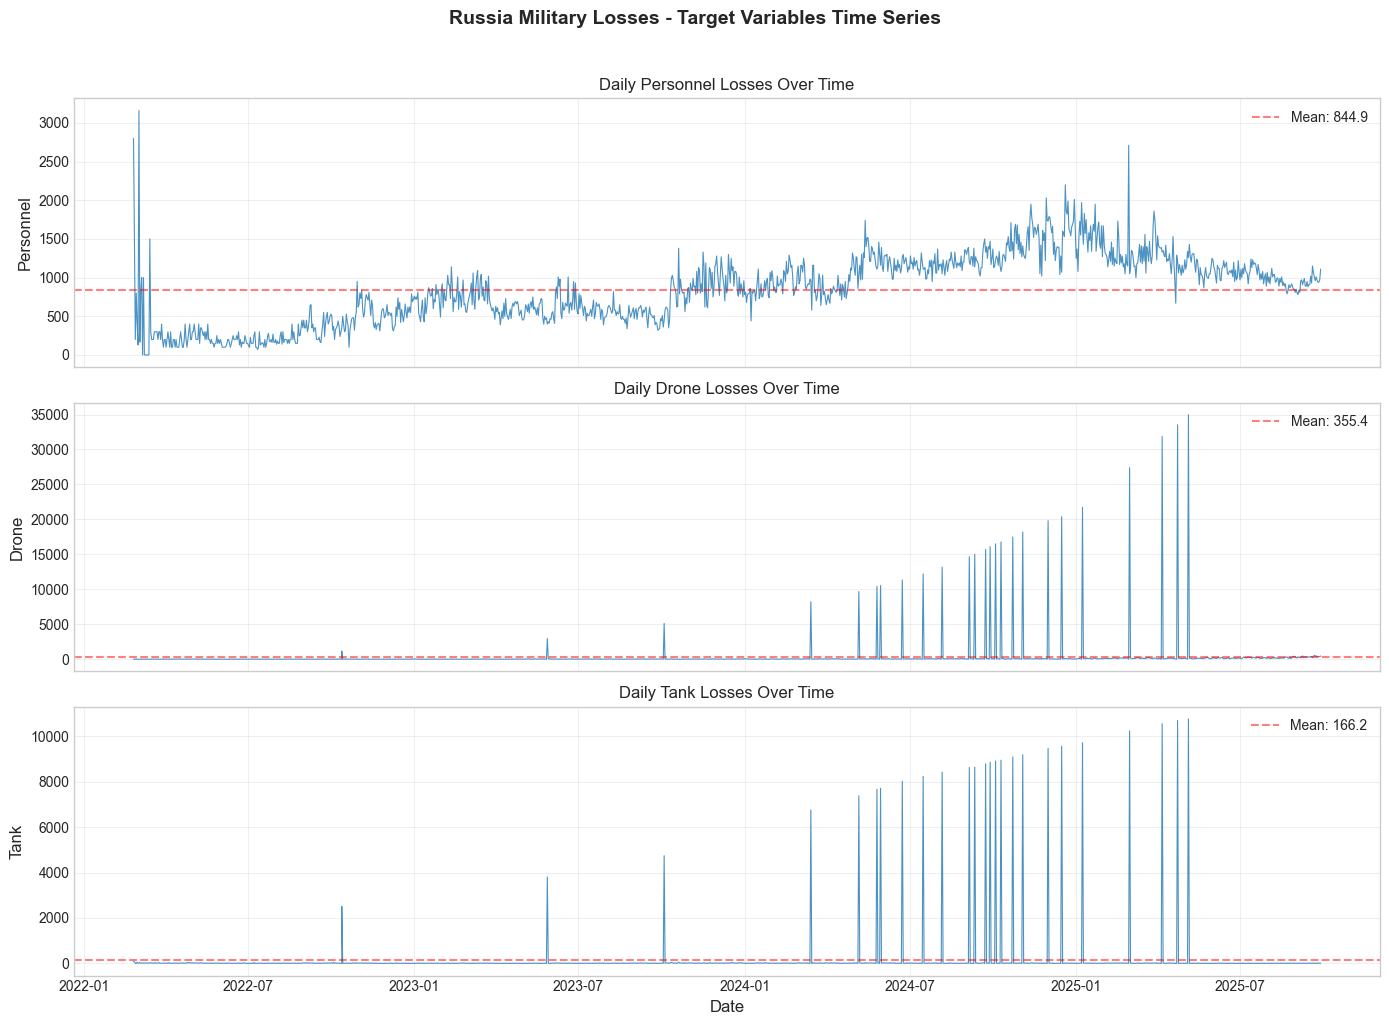

In [12]:
# =============================================================================
# Phase 2: Exploratory Data Analysis (EDA)
# =============================================================================
# 2.1 Time Series Visualization of Target Variables
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    ax.plot(df['date'], df[target], linewidth=0.8, alpha=0.8)
    ax.set_ylabel(target.capitalize(), fontsize=12)
    ax.set_title(f'Daily {target.capitalize()} Losses Over Time', fontsize=12)
    ax.axhline(y=df[target].mean(), color='red', linestyle='--', alpha=0.5, label=f'Mean: {df[target].mean():.1f}')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=12)
plt.suptitle('Russia Military Losses - Target Variables Time Series', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

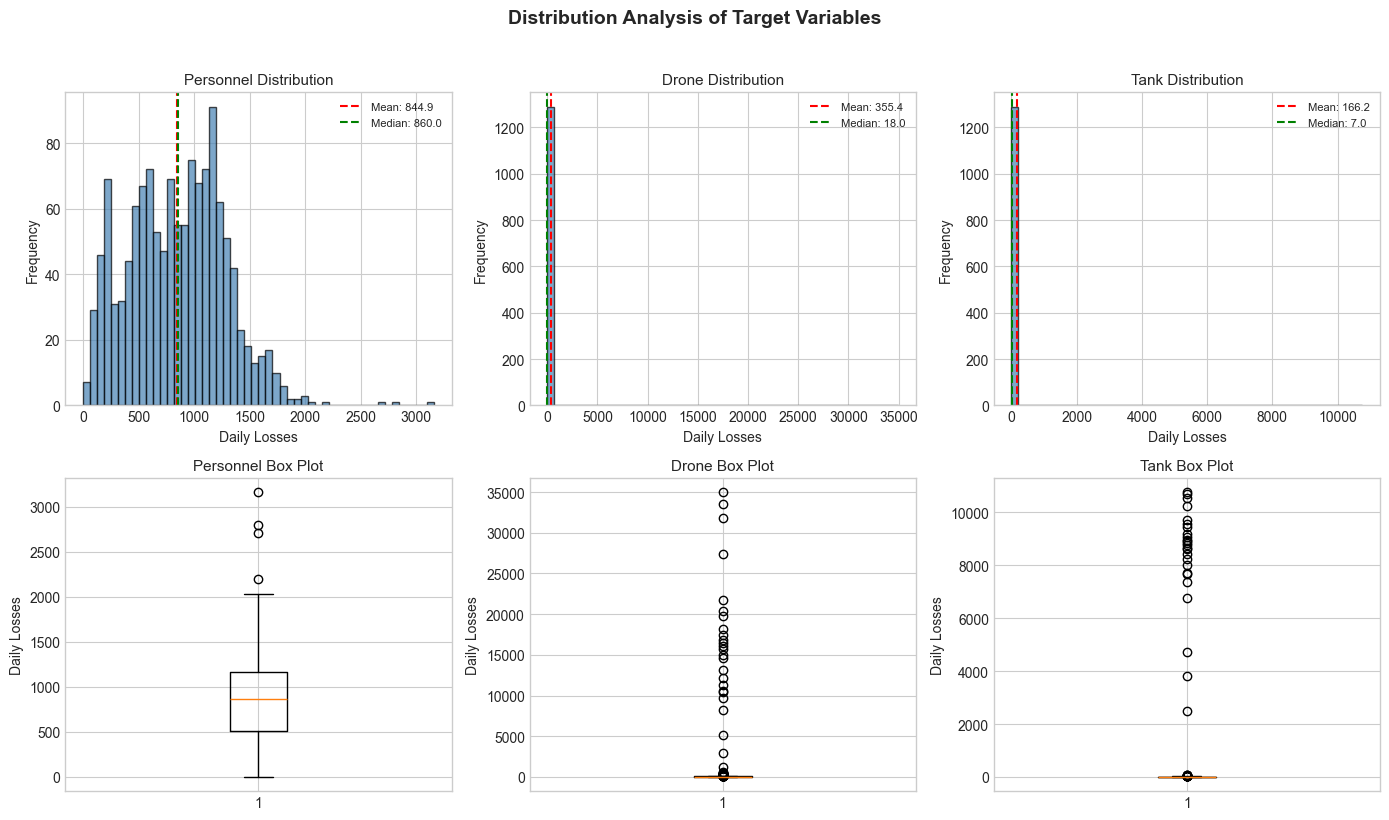

Distribution Statistics:

PERSONNEL:
  Skewness: 0.300
  Kurtosis: 0.332

DRONE:
  Skewness: 9.485
  Kurtosis: 99.912

TANK:
  Skewness: 7.495
  Kurtosis: 55.502


In [13]:
# =============================================================================
# 2.2 Distribution Analysis of Target Variables
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for idx, target in enumerate(TARGET_COLS):
    # Histogram
    axes[0, idx].hist(df[target], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0, idx].set_title(f'{target.capitalize()} Distribution', fontsize=11)
    axes[0, idx].set_xlabel('Daily Losses')
    axes[0, idx].set_ylabel('Frequency')
    axes[0, idx].axvline(df[target].mean(), color='red', linestyle='--', label=f'Mean: {df[target].mean():.1f}')
    axes[0, idx].axvline(df[target].median(), color='green', linestyle='--', label=f'Median: {df[target].median():.1f}')
    axes[0, idx].legend(fontsize=8)
    
    # Box plot
    axes[1, idx].boxplot(df[target].dropna(), vert=True)
    axes[1, idx].set_title(f'{target.capitalize()} Box Plot', fontsize=11)
    axes[1, idx].set_ylabel('Daily Losses')

plt.suptitle('Distribution Analysis of Target Variables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print skewness and kurtosis
print("Distribution Statistics:")
for target in TARGET_COLS:
    from scipy import stats
    print(f"\n{target.upper()}:")
    print(f"  Skewness: {df[target].skew():.3f}")
    print(f"  Kurtosis: {df[target].kurtosis():.3f}")

In [14]:
# Remove outliers for in TARGET_COLS
for target in TARGET_COLS:
    q1 = df[target].quantile(0.25)
    q3 = df[target].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df = df[(df[target] >= lower_bound) & (df[target] <= upper_bound)]

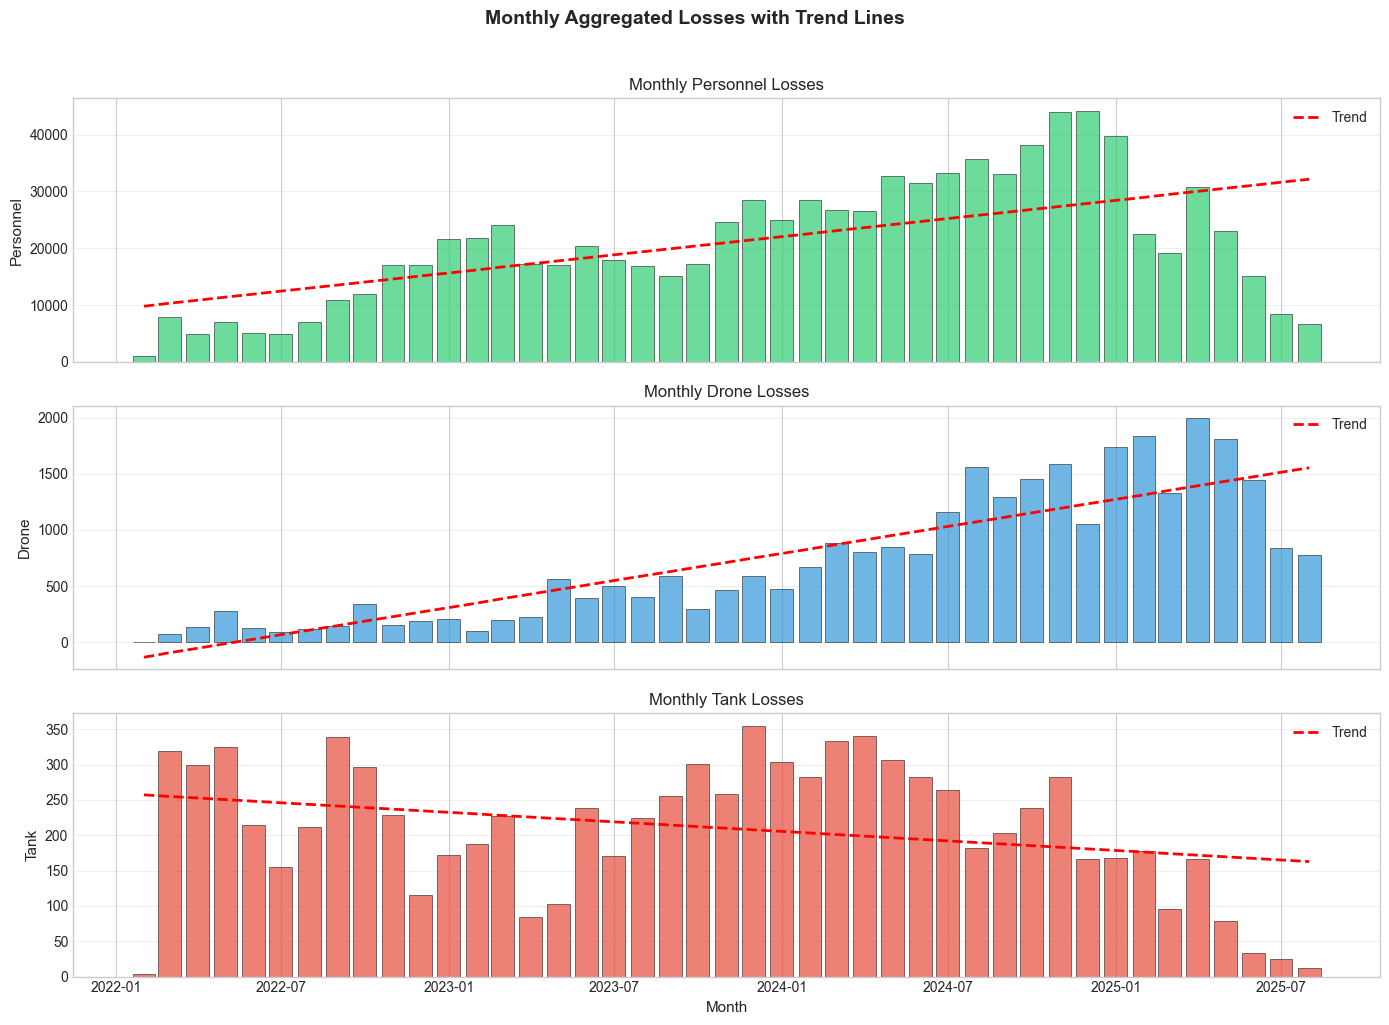

In [15]:
# =============================================================================
# 2.3 Monthly Aggregation & Trends
# =============================================================================

monthly_df = df.groupby([df['date'].dt.to_period('M')])[TARGET_COLS].sum().reset_index()
monthly_df['date'] = monthly_df['date'].dt.to_timestamp()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

colors = ['#2ecc71', '#3498db', '#e74c3c']

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    ax.bar(monthly_df['date'], monthly_df[target], width=25, alpha=0.7, color=colors[idx], edgecolor='black', linewidth=0.5)
    
    # Add trend line
    z = np.polyfit(range(len(monthly_df)), monthly_df[target], 1)
    p = np.poly1d(z)
    ax.plot(monthly_df['date'], p(range(len(monthly_df))), "r--", linewidth=2, label='Trend')
    
    ax.set_ylabel(f'{target.capitalize()}', fontsize=11)
    ax.set_title(f'Monthly {target.capitalize()} Losses', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

axes[-1].set_xlabel('Month', fontsize=11)
plt.suptitle('Monthly Aggregated Losses with Trend Lines', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

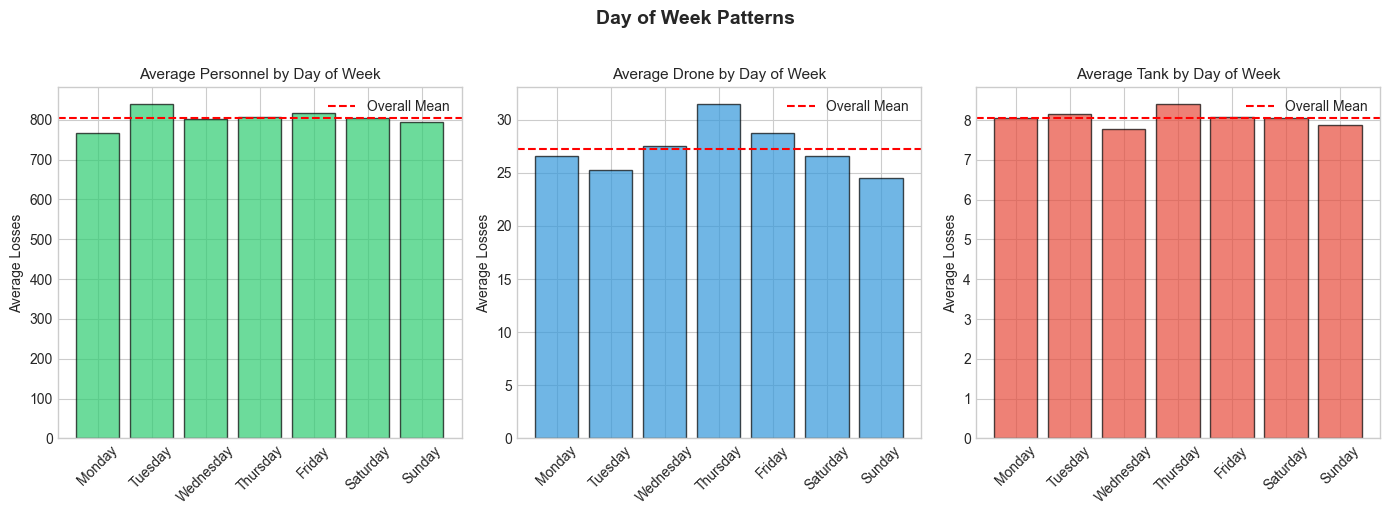

In [16]:
# =============================================================================
# 2.4 Day of Week Analysis
# =============================================================================

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for idx, target in enumerate(TARGET_COLS):
    day_avg = df.groupby('day_of_week')[target].mean()
    axes[idx].bar(day_names, day_avg.values, color=colors[idx], alpha=0.7, edgecolor='black')
    axes[idx].axhline(y=df[target].mean(), color='red', linestyle='--', label='Overall Mean')
    axes[idx].set_title(f'Average {target.capitalize()} by Day of Week', fontsize=11)
    axes[idx].set_ylabel('Average Losses')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].legend()

plt.suptitle('Day of Week Patterns', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

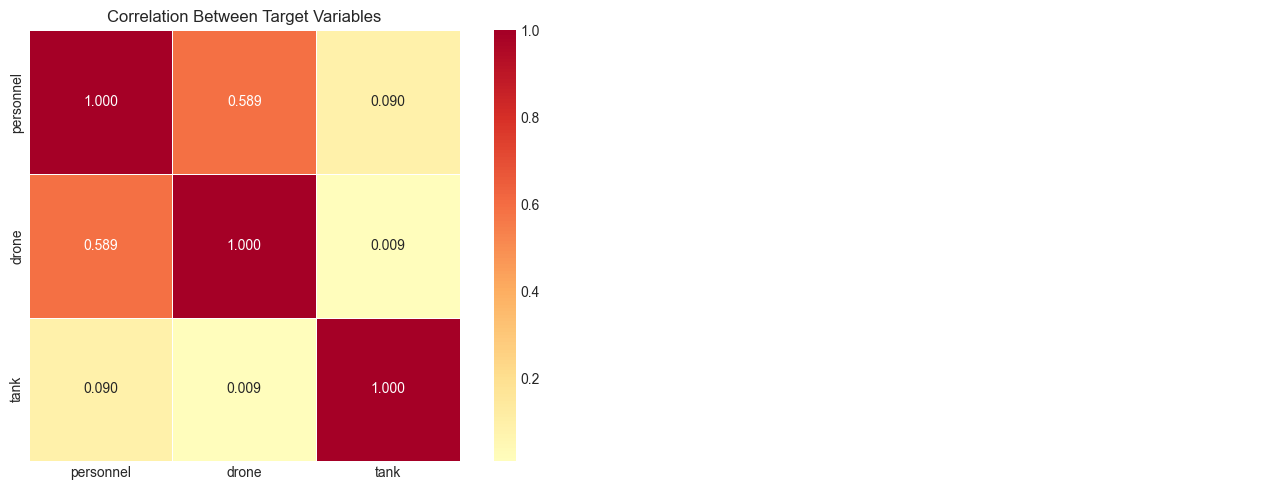

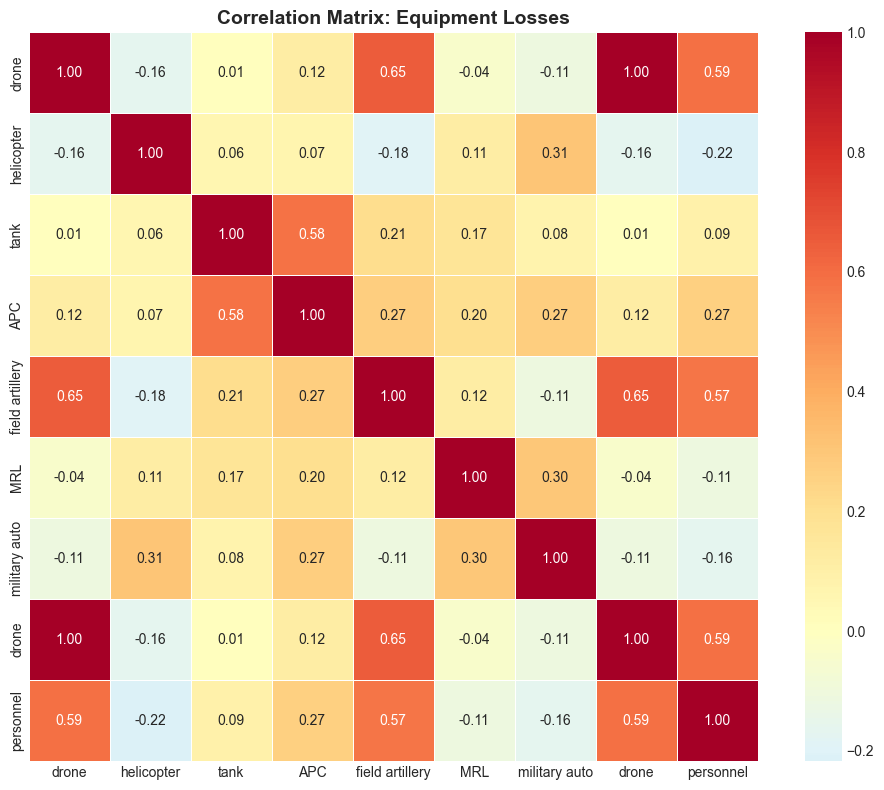

In [17]:
# =============================================================================
# 2.5 Correlation Analysis
# =============================================================================

# Correlation between target variables
target_corr = df[TARGET_COLS].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of target correlations
sns.heatmap(target_corr, annot=True, cmap='RdYlBu_r', center=0, 
            fmt='.3f', ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Correlation Between Target Variables', fontsize=12)

# Scatter matrix of targets
from pandas.plotting import scatter_matrix
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Extended correlation with other equipment
equipment_cols = ['drone', 'helicopter', 'tank', 'APC', 'field artillery', 'MRL', 
                  'military auto', 'drone', 'personnel']
equipment_corr = df[equipment_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(equipment_corr, annot=True, cmap='RdYlBu_r', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix: Equipment Losses', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

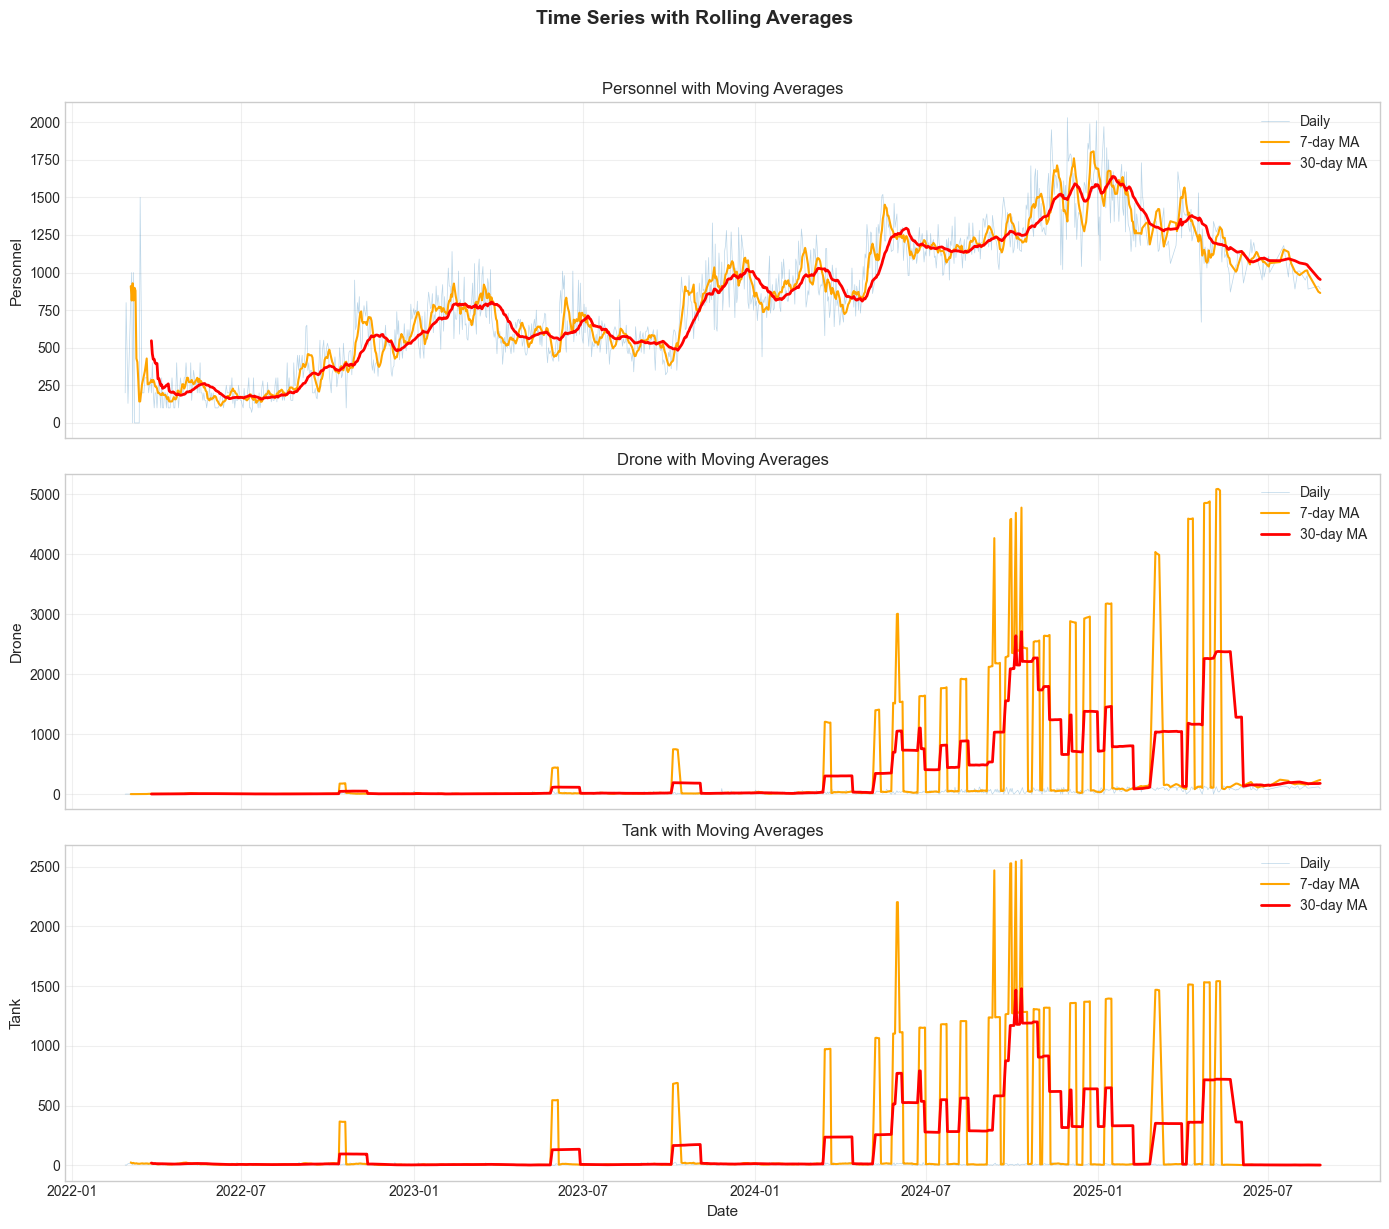

In [18]:
# =============================================================================
# 2.6 Rolling Statistics Visualization
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    ax.plot(df['date'], df[target], alpha=0.3, linewidth=0.5, label='Daily')
    ax.plot(df['date'], df[f'{target}_rolling_mean_7'], linewidth=1.5, label='7-day MA', color='orange')
    ax.plot(df['date'], df[f'{target}_rolling_mean_30'], linewidth=2, label='30-day MA', color='red')
    ax.set_ylabel(target.capitalize(), fontsize=11)
    ax.set_title(f'{target.capitalize()} with Moving Averages', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=11)
plt.suptitle('Time Series with Rolling Averages', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# =============================================================================
# Phase 3: Time Series Analysis
# =============================================================================
# 3.1 Stationarity Tests (Augmented Dickey-Fuller Test)
# =============================================================================

from statsmodels.tsa.stattools import adfuller, kpss

def adf_test(series, name):
    """Perform Augmented Dickey-Fuller test for stationarity."""
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"\n{name.upper()} - ADF Test Results:")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4f}")
    print(f"  Critical Values:")
    for key, value in result[4].items():
        print(f"    {key}: {value:.4f}")
    
    if result[1] <= 0.05:
        print(f"  Conclusion: Series is STATIONARY (reject H0)")
        return True
    else:
        print(f"  Conclusion: Series is NON-STATIONARY (fail to reject H0)")
        return False

print("=" * 60)
print("STATIONARITY ANALYSIS")
print("=" * 60)

stationarity_results = {}
for target in TARGET_COLS:
    stationarity_results[target] = adf_test(df[target], target)

STATIONARITY ANALYSIS

PERSONNEL - ADF Test Results:
  ADF Statistic: -1.3607
  p-value: 0.6010
  Critical Values:
    1%: -3.4363
    5%: -2.8642
    10%: -2.5682
  Conclusion: Series is NON-STATIONARY (fail to reject H0)

DRONE - ADF Test Results:
  ADF Statistic: -0.2509
  p-value: 0.9322
  Critical Values:
    1%: -3.4363
    5%: -2.8642
    10%: -2.5682
  Conclusion: Series is NON-STATIONARY (fail to reject H0)

TANK - ADF Test Results:
  ADF Statistic: -7.0457
  p-value: 0.0000
  Critical Values:
    1%: -3.4362
    5%: -2.8641
    10%: -2.5682
  Conclusion: Series is STATIONARY (reject H0)


In [20]:
# =============================================================================
# 3.1.1 Handle Non-Stationary Series (Differencing)
# =============================================================================

from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, name, alpha=0.05):
    """Check stationarity and return required differencing order."""
    result = adfuller(series.dropna(), autolag='AIC')
    is_stationary = result[1] <= alpha
    return is_stationary, result[1], result[0]

print("=" * 60)
print("STATIONARITY CHECK & DIFFERENCING")
print("=" * 60)

differencing_order = {}

for target in TARGET_COLS:
    series = df[target].dropna()
    is_stat, p_val, adf_stat = check_stationarity(series, target)
    
    print(f"\n{target.upper()}:")
    print(f"  Original - ADF Statistic: {adf_stat:.4f}, p-value: {p_val:.4f}")
    
    if is_stat:
        print(f"  Status: STATIONARY - No differencing needed")
        differencing_order[target] = 0
    else:
        # Apply first differencing
        series_diff1 = series.diff().dropna()
        is_stat_d1, p_val_d1, adf_stat_d1 = check_stationarity(series_diff1, f"{target}_diff1")
        
        print(f"  Status: NON-STATIONARY - Applying differencing...")
        print(f"  After 1st diff - ADF Statistic: {adf_stat_d1:.4f}, p-value: {p_val_d1:.4f}")
        
        if is_stat_d1:
            print(f"  Result: Stationary after d=1")
            differencing_order[target] = 1
            # Create differenced column for modeling
            df[f'{target}_diff'] = df[target].diff()
        else:
            # Apply second differencing
            series_diff2 = series_diff1.diff().dropna()
            is_stat_d2, p_val_d2, adf_stat_d2 = check_stationarity(series_diff2, f"{target}_diff2")
            print(f"  After 2nd diff - ADF Statistic: {adf_stat_d2:.4f}, p-value: {p_val_d2:.4f}")
            
            if is_stat_d2:
                print(f"  Result: Stationary after d=2")
                differencing_order[target] = 2
                df[f'{target}_diff'] = df[target].diff()
                df[f'{target}_diff2'] = df[f'{target}_diff'].diff()
            else:
                print(f"  Warning: Still non-stationary after d=2")
                differencing_order[target] = 1
                df[f'{target}_diff'] = df[target].diff()

print("\n" + "=" * 60)
print("DIFFERENCING SUMMARY")
print("=" * 60)
for target, d in differencing_order.items():
    print(f"  {target}: d = {d}")

STATIONARITY CHECK & DIFFERENCING

PERSONNEL:
  Original - ADF Statistic: -1.3607, p-value: 0.6010
  Status: NON-STATIONARY - Applying differencing...
  After 1st diff - ADF Statistic: -13.0017, p-value: 0.0000
  Result: Stationary after d=1

DRONE:
  Original - ADF Statistic: -0.2509, p-value: 0.9322
  Status: NON-STATIONARY - Applying differencing...
  After 1st diff - ADF Statistic: -14.3993, p-value: 0.0000
  Result: Stationary after d=1

TANK:
  Original - ADF Statistic: -7.0457, p-value: 0.0000
  Status: STATIONARY - No differencing needed

DIFFERENCING SUMMARY
  personnel: d = 1
  drone: d = 1
  tank: d = 0


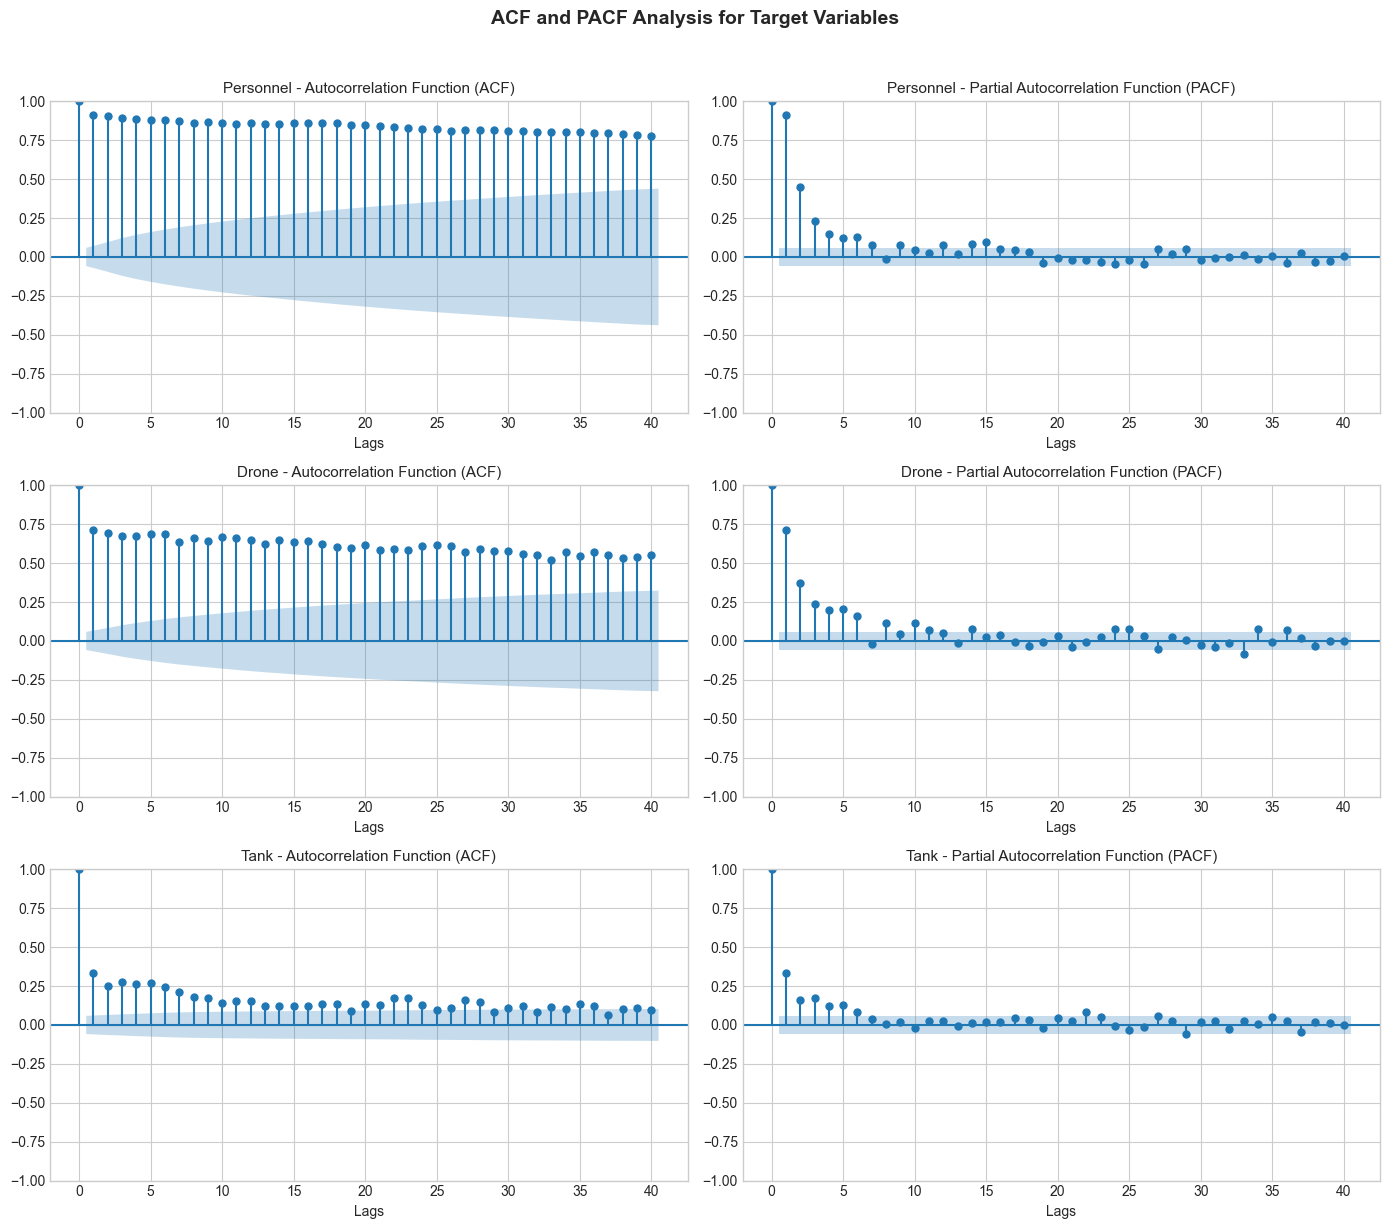


ACF/PACF Interpretation Guide:
- ACF shows correlation between time series and its lagged values
- PACF shows direct correlation after removing intermediate effects
- Significant spikes suggest AR/MA order for ARIMA models


In [21]:
# =============================================================================
# 3.2 ACF and PACF Analysis
# =============================================================================

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for idx, target in enumerate(TARGET_COLS):
    series = df[target].dropna()
    
    # ACF
    plot_acf(series, ax=axes[idx, 0], lags=40, alpha=0.05)
    axes[idx, 0].set_title(f'{target.capitalize()} - Autocorrelation Function (ACF)', fontsize=11)
    axes[idx, 0].set_xlabel('Lags')
    
    # PACF
    plot_pacf(series, ax=axes[idx, 1], lags=40, alpha=0.05, method='ywm')
    axes[idx, 1].set_title(f'{target.capitalize()} - Partial Autocorrelation Function (PACF)', fontsize=11)
    axes[idx, 1].set_xlabel('Lags')

plt.suptitle('ACF and PACF Analysis for Target Variables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nACF/PACF Interpretation Guide:")
print("- ACF shows correlation between time series and its lagged values")
print("- PACF shows direct correlation after removing intermediate effects")
print("- Significant spikes suggest AR/MA order for ARIMA models")

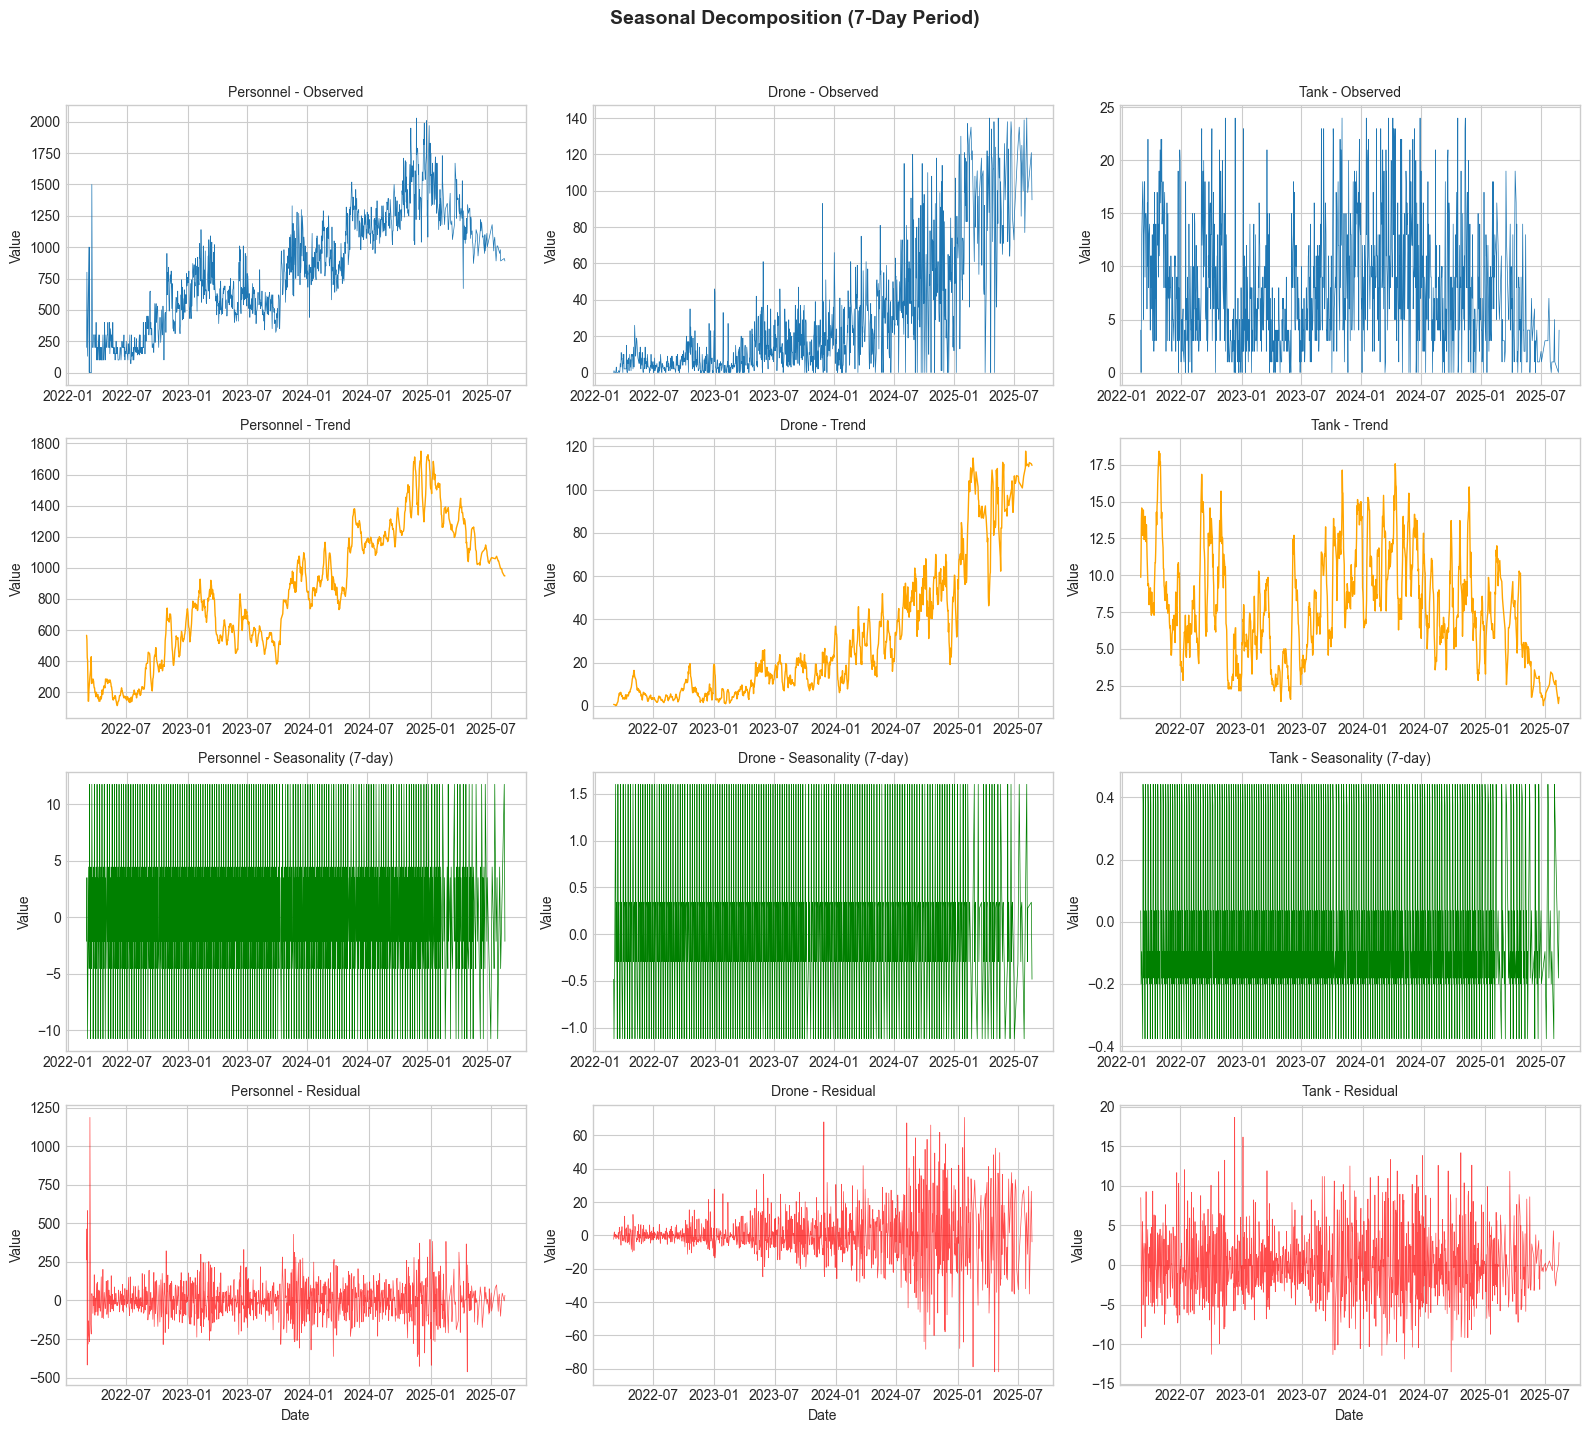

In [22]:
# =============================================================================
# 3.3 Seasonal Decomposition
# =============================================================================

from statsmodels.tsa.seasonal import seasonal_decompose

fig, axes = plt.subplots(4, 3, figsize=(16, 14))

for idx, target in enumerate(TARGET_COLS):
    series = df.set_index('date')[target].dropna()
    
    # Perform decomposition (using 7-day period for weekly seasonality)
    decomposition = seasonal_decompose(series, model='additive', period=7)
    
    axes[0, idx].plot(decomposition.observed, linewidth=0.5)
    axes[0, idx].set_title(f'{target.capitalize()} - Observed', fontsize=10)
    axes[0, idx].set_ylabel('Value')
    
    axes[1, idx].plot(decomposition.trend, linewidth=1, color='orange')
    axes[1, idx].set_title(f'{target.capitalize()} - Trend', fontsize=10)
    axes[1, idx].set_ylabel('Value')
    
    axes[2, idx].plot(decomposition.seasonal, linewidth=0.5, color='green')
    axes[2, idx].set_title(f'{target.capitalize()} - Seasonality (7-day)', fontsize=10)
    axes[2, idx].set_ylabel('Value')
    
    axes[3, idx].plot(decomposition.resid, linewidth=0.5, color='red', alpha=0.7)
    axes[3, idx].set_title(f'{target.capitalize()} - Residual', fontsize=10)
    axes[3, idx].set_ylabel('Value')
    axes[3, idx].set_xlabel('Date')

plt.suptitle('Seasonal Decomposition (7-Day Period)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [23]:
# =============================================================================
# Phase 4: Train/Validation/Test Split
# =============================================================================
# 4.1 Chronological Data Split (80/10/10)
# =============================================================================

# Drop rows with NaN values from lag/rolling features
df_clean = df.dropna().reset_index(drop=True)
print(f"Dataset after dropping NaN: {df_clean.shape[0]} rows (dropped {len(df) - len(df_clean)} rows)")

# Chronological split
train_size = int(len(df_clean) * 0.8)
val_size = int(len(df_clean) * 0.1)

train_df = df_clean[:train_size].copy()
val_df = df_clean[train_size:train_size + val_size].copy()
test_df = df_clean[train_size + val_size:].copy()

print(f"\nData Split Summary:")
print(f"  Training set:   {len(train_df)} samples ({len(train_df)/len(df_clean)*100:.1f}%)")
print(f"    Date range: {train_df['date'].min().strftime('%Y-%m-%d')} to {train_df['date'].max().strftime('%Y-%m-%d')}")
print(f"  Validation set: {len(val_df)} samples ({len(val_df)/len(df_clean)*100:.1f}%)")
print(f"    Date range: {val_df['date'].min().strftime('%Y-%m-%d')} to {val_df['date'].max().strftime('%Y-%m-%d')}")
print(f"  Test set:       {len(test_df)} samples ({len(test_df)/len(df_clean)*100:.1f}%)")
print(f"    Date range: {test_df['date'].min().strftime('%Y-%m-%d')} to {test_df['date'].max().strftime('%Y-%m-%d')}")

Dataset after dropping NaN: 196 rows (dropped 925 rows)

Data Split Summary:
  Training set:   156 samples (79.6%)
    Date range: 2022-04-25 to 2022-10-06
  Validation set: 19 samples (9.7%)
    Date range: 2022-10-07 to 2022-11-09
  Test set:       21 samples (10.7%)
    Date range: 2022-11-10 to 2023-01-02


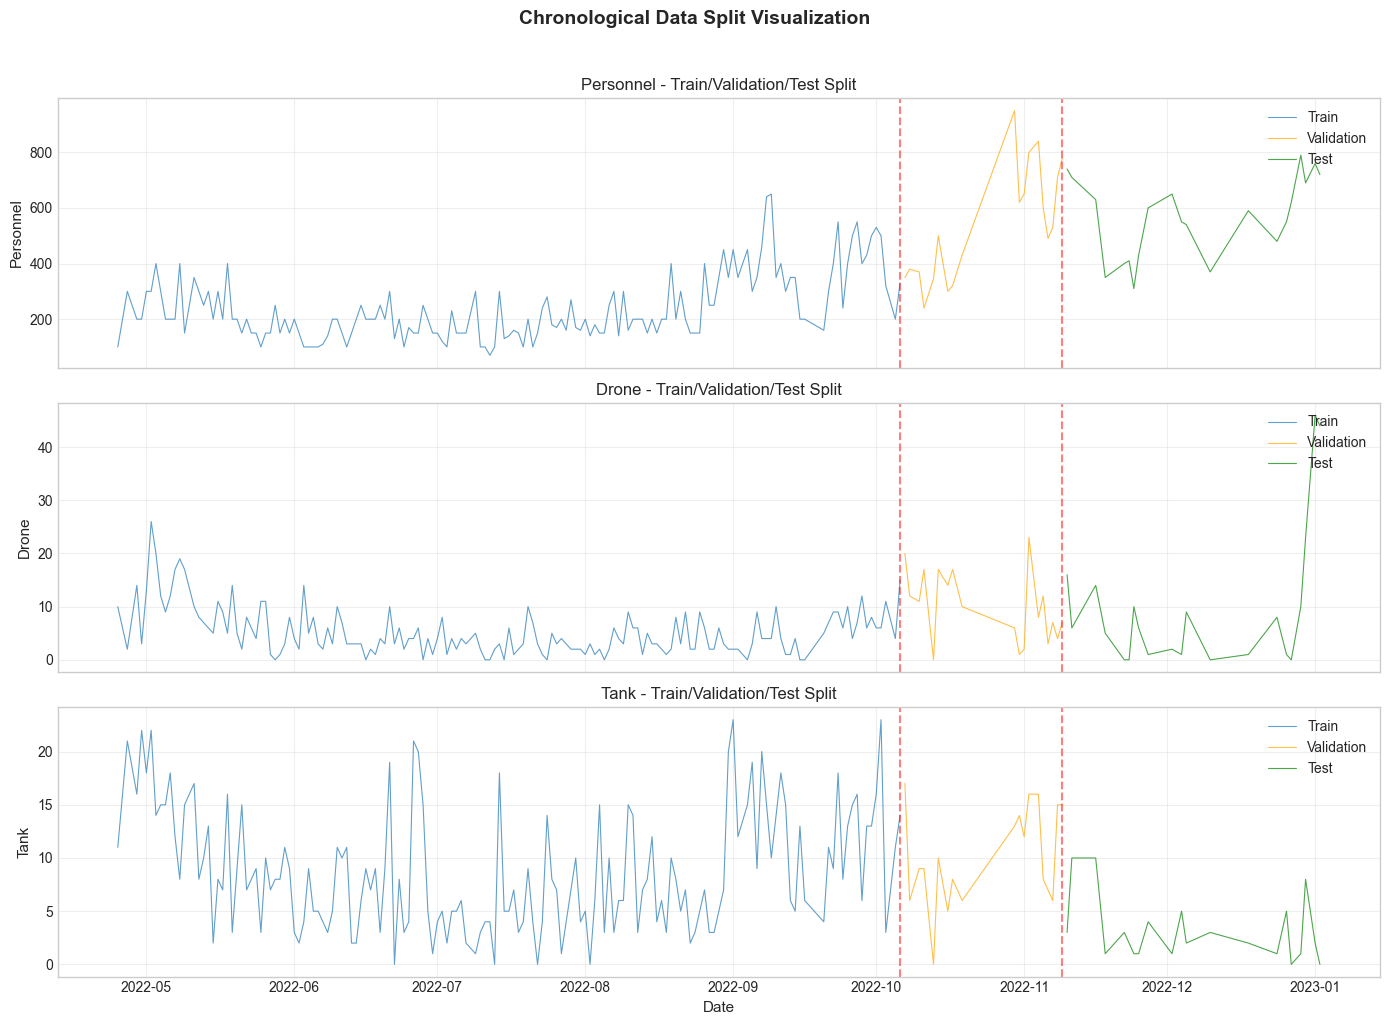

In [24]:
# =============================================================================
# 4.2 Visualize Train/Val/Test Split
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    
    ax.plot(train_df['date'], train_df[target], label='Train', alpha=0.7, linewidth=0.8)
    ax.plot(val_df['date'], val_df[target], label='Validation', alpha=0.7, linewidth=0.8, color='orange')
    ax.plot(test_df['date'], test_df[target], label='Test', alpha=0.7, linewidth=0.8, color='green')
    
    # Add vertical lines for split points
    ax.axvline(x=train_df['date'].max(), color='red', linestyle='--', alpha=0.5)
    ax.axvline(x=val_df['date'].max(), color='red', linestyle='--', alpha=0.5)
    
    ax.set_ylabel(target.capitalize(), fontsize=11)
    ax.set_title(f'{target.capitalize()} - Train/Validation/Test Split', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=11)
plt.suptitle('Chronological Data Split Visualization', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# =============================================================================
# 4.3 Prepare Feature Sets for ML Models
# =============================================================================

# Define feature columns (exclude target, date, and non-numeric columns)
exclude_cols = TARGET_COLS + ['date', 'day', 'greatest losses direction']

# Get all feature columns for ML models
feature_cols = [col for col in df_clean.columns if col not in exclude_cols 
                and df_clean[col].dtype in ['int64', 'float64', 'int32', 'float32']]

print(f"Number of features for ML models: {len(feature_cols)}")
print(f"\nFeature columns:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

# Prepare X and y for each target
X_train = train_df[feature_cols]
X_val = val_df[feature_cols]
X_test = test_df[feature_cols]

y_train = {target: train_df[target] for target in TARGET_COLS}
y_val = {target: val_df[target] for target in TARGET_COLS}
y_test = {target: test_df[target] for target in TARGET_COLS}

print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")

Number of features for ML models: 96

Feature columns:
  1. aircraft
  2. helicopter
  3. APC
  4. field artillery
  5. MRL
  6. military auto
  7. fuel tank
  8. naval ship
  9. anti-aircraft warfare
  10. special equipment
  11. mobile SRBM system
  12. vehicles and fuel tanks
  13. cruise missiles
  14. submarines
  15. year
  16. month
  17. day_of_week
  18. day_of_month
  19. week_of_year
  20. quarter
  21. is_weekend
  22. days_since_start
  23. personnel_lag_1
  24. personnel_lag_3
  25. personnel_lag_7
  26. personnel_lag_14
  27. personnel_lag_30
  28. drone_lag_1
  29. drone_lag_3
  30. drone_lag_7
  31. drone_lag_14
  32. drone_lag_30
  33. tank_lag_1
  34. tank_lag_3
  35. tank_lag_7
  36. tank_lag_14
  37. tank_lag_30
  38. personnel_rolling_mean_7
  39. personnel_rolling_std_7
  40. personnel_rolling_min_7
  41. personnel_rolling_max_7
  42. personnel_rolling_mean_14
  43. personnel_rolling_std_14
  44. personnel_rolling_min_14
  45. personnel_rolling_max_14
  46. perso

In [26]:
# =============================================================================
# 4.4 Feature Scaling (for Neural Networks)
# =============================================================================

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Standard Scaler for features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

# MinMax Scaler for targets (useful for LSTM)
scalers_y = {}
y_train_scaled = {}
y_val_scaled = {}
y_test_scaled = {}

for target in TARGET_COLS:
    scalers_y[target] = MinMaxScaler()
    y_train_scaled[target] = scalers_y[target].fit_transform(y_train[target].values.reshape(-1, 1)).flatten()
    y_val_scaled[target] = scalers_y[target].transform(y_val[target].values.reshape(-1, 1)).flatten()
    y_test_scaled[target] = scalers_y[target].transform(y_test[target].values.reshape(-1, 1)).flatten()

print("Feature and target scaling completed!")
print(f"\nScaled feature ranges:")
print(f"  X_train_scaled: mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}")
print(f"\nScaled target ranges (MinMax 0-1):")
for target in TARGET_COLS:
    print(f"  {target}: min={y_train_scaled[target].min():.4f}, max={y_train_scaled[target].max():.4f}")

Feature and target scaling completed!

Scaled feature ranges:
  X_train_scaled: mean=-0.0000, std=0.9789

Scaled target ranges (MinMax 0-1):
  personnel: min=0.0000, max=1.0000
  drone: min=0.0000, max=1.0000
  tank: min=0.0000, max=1.0000


In [27]:
# =============================================================================
# Phase 5: Baseline Models
# =============================================================================
# 5.1 Evaluation Metrics
# =============================================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def calculate_metrics(y_true, y_pred, model_name=""):
    """Calculate comprehensive evaluation metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100  # Add small value to avoid division by zero
    r2 = r2_score(y_true, y_pred)
    
    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2
    }

# Store all results
all_results = {target: [] for target in TARGET_COLS}

print("Evaluation metrics defined:")
print("  - MAE  (Mean Absolute Error)")
print("  - MSE  (Mean Squared Error)")
print("  - RMSE (Root Mean Squared Error)")
print("  - MAPE (Mean Absolute Percentage Error)")
print("  - R2   (R-squared / Coefficient of Determination)")

Evaluation metrics defined:
  - MAE  (Mean Absolute Error)
  - MSE  (Mean Squared Error)
  - RMSE (Root Mean Squared Error)
  - MAPE (Mean Absolute Percentage Error)
  - R2   (R-squared / Coefficient of Determination)


In [28]:
# =============================================================================
# 5.2 Baseline 0: Naive (Last Value) Forecast
# =============================================================================

print("=" * 60)
print("BASELINE 1: NAIVE FORECAST (Last Value)")
print("=" * 60)

naive_predictions = {}

for target in TARGET_COLS:
    # Naive forecast: predict the previous day's value
    naive_pred = test_df[f'{target}_lag_1'].values
    naive_predictions[target] = naive_pred
    
    # Calculate metrics
    metrics = calculate_metrics(y_test[target].values, naive_pred, "Naive (Lag-1)")
    all_results[target].append(metrics)
    
    print(f"\n{target.upper()}:")
    print(f"  MAE:  {metrics['MAE']:.2f}")
    print(f"  RMSE: {metrics['RMSE']:.2f}")
    print(f"  R2:   {metrics['R2']:.4f}")

BASELINE 1: NAIVE FORECAST (Last Value)

PERSONNEL:
  MAE:  70.95
  RMSE: 88.99
  R2:   0.6071

DRONE:
  MAE:  6.38
  RMSE: 10.79
  R2:   0.3058

TANK:
  MAE:  3.10
  RMSE: 4.25
  R2:   -1.1315


In [29]:
# =============================================================================
# 5.2 Baseline 1: Naive (Last Value) Forecast Plus Mean Difference
# =============================================================================

print("=" * 60)
print("BASELINE 2: NAIVE FORECAST + MEAN DIFFERENCE")
print("=" * 60)

naive_mean_diff_predictions = {}

for target in TARGET_COLS:
    # Calculate mean daily difference in training set
    mean_diff = train_df[target].diff().mean()
    
    # Naive forecast + mean difference
    naive_mean_diff_pred = test_df[f'{target}_lag_1'].values + mean_diff
    naive_mean_diff_predictions[target] = naive_mean_diff_pred
    
    # Calculate metrics
    metrics = calculate_metrics(y_test[target].values, naive_mean_diff_pred, "Naive (Lag-1) + Mean Diff")
    all_results[target].append(metrics)
    
    print(f"\n{target.upper()}:")
    print(f"  MAE:  {metrics['MAE']:.2f}")
    print(f"  RMSE: {metrics['RMSE']:.2f}")
    print(f"  R2:   {metrics['R2']:.4f}")

BASELINE 2: NAIVE FORECAST + MEAN DIFFERENCE

PERSONNEL:
  MAE:  70.88
  RMSE: 88.75
  R2:   0.6092

DRONE:
  MAE:  6.38
  RMSE: 10.78
  R2:   0.3073

TANK:
  MAE:  3.11
  RMSE: 4.25
  R2:   -1.1357


In [30]:
# =============================================================================
# 5.3 Baseline 2: Moving Average Forecast
# =============================================================================

print("=" * 60)
print("BASELINE 2: MOVING AVERAGE FORECAST (7-day)")
print("=" * 60)

ma_predictions = {}

for target in TARGET_COLS:
    # 7-day moving average as prediction
    ma_pred = test_df[f'{target}_rolling_mean_7'].values
    ma_predictions[target] = ma_pred
    
    # Calculate metrics
    metrics = calculate_metrics(y_test[target].values, ma_pred, "Moving Average (7-day)")
    all_results[target].append(metrics)
    
    print(f"\n{target.upper()}:")
    print(f"  MAE:  {metrics['MAE']:.2f}")
    print(f"  RMSE: {metrics['RMSE']:.2f}")
    print(f"  R2:   {metrics['R2']:.4f}")

BASELINE 2: MOVING AVERAGE FORECAST (7-day)

PERSONNEL:
  MAE:  82.59
  RMSE: 108.27
  R2:   0.4184

DRONE:
  MAE:  8.36
  RMSE: 13.03
  R2:   -0.0123

TANK:
  MAE:  2.87
  RMSE: 3.85
  R2:   -0.7535


In [31]:
# =============================================================================
# 5.4 Baseline 3: Exponential Moving Average Forecast
# =============================================================================

print("=" * 60)
print("BASELINE 3: EXPONENTIAL MOVING AVERAGE FORECAST (7-day)")
print("=" * 60)

ema_predictions = {}

for target in TARGET_COLS:
    # 7-day EMA as prediction
    ema_pred = test_df[f'{target}_ema_7'].values
    ema_predictions[target] = ema_pred
    
    # Calculate metrics
    metrics = calculate_metrics(y_test[target].values, ema_pred, "EMA (7-day)")
    all_results[target].append(metrics)
    
    print(f"\n{target.upper()}:")
    print(f"  MAE:  {metrics['MAE']:.2f}")
    print(f"  RMSE: {metrics['RMSE']:.2f}")
    print(f"  R2:   {metrics['R2']:.4f}")

BASELINE 3: EXPONENTIAL MOVING AVERAGE FORECAST (7-day)

PERSONNEL:
  MAE:  75.62
  RMSE: 100.05
  R2:   0.5034

DRONE:
  MAE:  7.59
  RMSE: 11.82
  R2:   0.1662

TANK:
  MAE:  2.90
  RMSE: 3.78
  R2:   -0.6879


In [32]:
# =============================================================================
# Phase 7: Machine Learning Models with Hyperparameter Tuning
# =============================================================================
# 7.0 Hyperparameter Tuning Setup
# =============================================================================

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import time

# Use TimeSeriesSplit for cross-validation (respects temporal order)
tscv = TimeSeriesSplit(n_splits=5)

print("=" * 60)
print("HYPERPARAMETER TUNING SETUP")
print("=" * 60)
print(f"Cross-validation strategy: TimeSeriesSplit with {tscv.n_splits} splits")
print(f"Training samples: {len(X_train)}")
print(f"Features: {len(feature_cols)}")

# Store best hyperparameters
best_params = {target: {} for target in TARGET_COLS}

HYPERPARAMETER TUNING SETUP
Cross-validation strategy: TimeSeriesSplit with 5 splits
Training samples: 156
Features: 96


In [33]:
# =============================================================================
# 7.0.1 Random Forest Hyperparameter Tuning
# =============================================================================

print("=" * 60)
print("RANDOM FOREST - HYPERPARAMETER TUNING")
print("=" * 60)

# Define hyperparameter search space
rf_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

rf_best_params = {}

for target in TARGET_COLS:
    print(f"\nTuning Random Forest for {target.upper()}...")
    start_time = time.time()
    
    rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
    
    rf_search = RandomizedSearchCV(
        estimator=rf_base,
        param_distributions=rf_param_grid,
        n_iter=30,  # Number of random combinations to try
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    
    rf_search.fit(X_train, y_train[target])
    
    rf_best_params[target] = rf_search.best_params_
    best_params[target]['RandomForest'] = rf_search.best_params_
    
    elapsed = time.time() - start_time
    print(f"  Time: {elapsed:.1f}s")
    print(f"  Best CV Score (RMSE): {-rf_search.best_score_:.2f}")
    print(f"  Best Parameters:")
    for param, value in rf_search.best_params_.items():
        print(f"    {param}: {value}")

RANDOM FOREST - HYPERPARAMETER TUNING

Tuning Random Forest for PERSONNEL...
  Time: 14.7s
  Best CV Score (RMSE): 76.33
  Best Parameters:
    n_estimators: 200
    min_samples_split: 2
    min_samples_leaf: 1
    max_features: sqrt
    max_depth: 5

Tuning Random Forest for DRONE...
  Time: 8.2s
  Best CV Score (RMSE): 2.16
  Best Parameters:
    n_estimators: 50
    min_samples_split: 2
    min_samples_leaf: 1
    max_features: None
    max_depth: 10

Tuning Random Forest for TANK...
  Time: 8.3s
  Best CV Score (RMSE): 3.47
  Best Parameters:
    n_estimators: 100
    min_samples_split: 5
    min_samples_leaf: 4
    max_features: None
    max_depth: 5


In [34]:
# =============================================================================
# 7.0.2 XGBoost Hyperparameter Tuning
# =============================================================================

print("=" * 60)
print("XGBOOST - HYPERPARAMETER TUNING")
print("=" * 60)

# Define hyperparameter search space
xgb_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2]
}

xgb_best_params = {}

for target in TARGET_COLS:
    print(f"\nTuning XGBoost for {target.upper()}...")
    start_time = time.time()
    
    xgb_base = XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)
    
    xgb_search = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=xgb_param_grid,
        n_iter=30,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    
    xgb_search.fit(X_train, y_train[target])
    
    xgb_best_params[target] = xgb_search.best_params_
    best_params[target]['XGBoost'] = xgb_search.best_params_
    
    elapsed = time.time() - start_time
    print(f"  Time: {elapsed:.1f}s")
    print(f"  Best CV Score (RMSE): {-xgb_search.best_score_:.2f}")
    print(f"  Best Parameters:")
    for param, value in xgb_search.best_params_.items():
        print(f"    {param}: {value}")

XGBOOST - HYPERPARAMETER TUNING

Tuning XGBoost for PERSONNEL...
  Time: 4.0s
  Best CV Score (RMSE): 59.66
  Best Parameters:
    subsample: 0.8
    n_estimators: 300
    min_child_weight: 5
    max_depth: 3
    learning_rate: 0.2
    gamma: 0
    colsample_bytree: 0.6

Tuning XGBoost for DRONE...
  Time: 3.4s
  Best CV Score (RMSE): 1.70
  Best Parameters:
    subsample: 1.0
    n_estimators: 300
    min_child_weight: 1
    max_depth: 3
    learning_rate: 0.2
    gamma: 0.1
    colsample_bytree: 0.8

Tuning XGBoost for TANK...
  Time: 3.4s
  Best CV Score (RMSE): 2.82
  Best Parameters:
    subsample: 0.8
    n_estimators: 100
    min_child_weight: 5
    max_depth: 3
    learning_rate: 0.1
    gamma: 0
    colsample_bytree: 1.0


In [35]:
# =============================================================================
# 7.0.3 LightGBM Hyperparameter Tuning
# =============================================================================

print("=" * 60)
print("LIGHTGBM - HYPERPARAMETER TUNING")
print("=" * 60)

# Define hyperparameter search space
lgbm_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 10, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'num_leaves': [15, 31, 63, 127],
    'min_child_samples': [5, 10, 20],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0, 0.1, 0.5]
}

lgbm_best_params = {}

for target in TARGET_COLS:
    print(f"\nTuning LightGBM for {target.upper()}...")
    start_time = time.time()
    
    lgbm_base = LGBMRegressor(random_state=42, verbosity=-1, n_jobs=-1)
    
    lgbm_search = RandomizedSearchCV(
        estimator=lgbm_base,
        param_distributions=lgbm_param_grid,
        n_iter=30,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    
    lgbm_search.fit(X_train, y_train[target])
    
    lgbm_best_params[target] = lgbm_search.best_params_
    best_params[target]['LightGBM'] = lgbm_search.best_params_
    
    elapsed = time.time() - start_time
    print(f"  Time: {elapsed:.1f}s")
    print(f"  Best CV Score (RMSE): {-lgbm_search.best_score_:.2f}")
    print(f"  Best Parameters:")
    for param, value in lgbm_search.best_params_.items():
        print(f"    {param}: {value}")

LIGHTGBM - HYPERPARAMETER TUNING

Tuning LightGBM for PERSONNEL...
  Time: 7.9s
  Best CV Score (RMSE): 59.61
  Best Parameters:
    subsample: 1.0
    reg_lambda: 0.1
    reg_alpha: 0
    num_leaves: 31
    n_estimators: 300
    min_child_samples: 5
    max_depth: -1
    learning_rate: 0.2
    colsample_bytree: 1.0

Tuning LightGBM for DRONE...
  Time: 6.1s
  Best CV Score (RMSE): 1.78
  Best Parameters:
    subsample: 0.8
    reg_lambda: 0.1
    reg_alpha: 0
    num_leaves: 15
    n_estimators: 200
    min_child_samples: 10
    max_depth: 3
    learning_rate: 0.2
    colsample_bytree: 1.0

Tuning LightGBM for TANK...
  Time: 6.5s
  Best CV Score (RMSE): 3.16
  Best Parameters:
    subsample: 1.0
    reg_lambda: 0
    reg_alpha: 0.5
    num_leaves: 15
    n_estimators: 50
    min_child_samples: 5
    max_depth: 3
    learning_rate: 0.1
    colsample_bytree: 1.0


In [36]:
# =============================================================================
# 7.0.4 Hyperparameter Tuning Summary
# =============================================================================

print("=" * 80)
print("HYPERPARAMETER TUNING SUMMARY")
print("=" * 80)

for target in TARGET_COLS:
    print(f"\n{target.upper()}:")
    print("-" * 40)
    for model_name, params in best_params[target].items():
        print(f"\n  {model_name}:")
        for param, value in params.items():
            print(f"    {param}: {value}")

HYPERPARAMETER TUNING SUMMARY

PERSONNEL:
----------------------------------------

  RandomForest:
    n_estimators: 200
    min_samples_split: 2
    min_samples_leaf: 1
    max_features: sqrt
    max_depth: 5

  XGBoost:
    subsample: 0.8
    n_estimators: 300
    min_child_weight: 5
    max_depth: 3
    learning_rate: 0.2
    gamma: 0
    colsample_bytree: 0.6

  LightGBM:
    subsample: 1.0
    reg_lambda: 0.1
    reg_alpha: 0
    num_leaves: 31
    n_estimators: 300
    min_child_samples: 5
    max_depth: -1
    learning_rate: 0.2
    colsample_bytree: 1.0

DRONE:
----------------------------------------

  RandomForest:
    n_estimators: 50
    min_samples_split: 2
    min_samples_leaf: 1
    max_features: None
    max_depth: 10

  XGBoost:
    subsample: 1.0
    n_estimators: 300
    min_child_weight: 1
    max_depth: 3
    learning_rate: 0.2
    gamma: 0.1
    colsample_bytree: 0.8

  LightGBM:
    subsample: 0.8
    reg_lambda: 0.1
    reg_alpha: 0
    num_leaves: 15
    n_es

In [37]:
# =============================================================================
# Phase 6: Statistical Models (ARIMA/SARIMA)
# =============================================================================
# 6.1 ARIMA Model (with correct differencing order)
# =============================================================================

from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("ARIMA MODEL (with stationarity-based differencing)")
print("=" * 60)

arima_predictions = {}
arima_models = {}

for target in TARGET_COLS:
    print(f"\nFitting ARIMA for {target.upper()}...")
    
    # Use training data for fitting
    train_series = train_df.set_index('date')[target]
    
    # Get the differencing order from stationarity analysis
    d = differencing_order.get(target, 0)
    
    # Fit ARIMA model with correct differencing order
    # Using (1,d,1) where d is determined by stationarity tests
    try:
        model = ARIMA(train_series, order=(1, d, 1))
        fitted_model = model.fit()
        arima_models[target] = fitted_model
        
        # Forecast for test period
        forecast = fitted_model.forecast(steps=len(test_df))
        arima_predictions[target] = forecast.values
        
        # Calculate metrics
        metrics = calculate_metrics(y_test[target].values, forecast.values, f"ARIMA(1,{d},1)")
        all_results[target].append(metrics)
        
        print(f"  Order: (1, {d}, 1)")
        print(f"  AIC: {fitted_model.aic:.2f}")
        print(f"  MAE:  {metrics['MAE']:.2f}")
        print(f"  RMSE: {metrics['RMSE']:.2f}")
        print(f"  R2:   {metrics['R2']:.4f}")
    except Exception as e:
        print(f"  Error fitting ARIMA: {e}")

ARIMA MODEL (with stationarity-based differencing)

Fitting ARIMA for PERSONNEL...
  Order: (1, 1, 1)
  AIC: 1824.48
  MAE:  198.79
  RMSE: 236.79
  R2:   -1.7818

Fitting ARIMA for DRONE...
  Order: (1, 1, 1)
  AIC: 849.96
  MAE:  8.60
  RMSE: 13.01
  R2:   -0.0092

Fitting ARIMA for TANK...
  Order: (1, 0, 1)
  AIC: 952.93
  MAE:  7.57
  RMSE: 8.06
  R2:   -6.6751


In [38]:
# =============================================================================
# 6.2 SARIMA Model (Seasonal ARIMA with correct differencing)
# =============================================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

print("=" * 60)
print("SARIMA MODEL (with stationarity-based differencing)")
print("=" * 60)

sarima_predictions = {}
sarima_models = {}

for target in TARGET_COLS:
    print(f"\nFitting SARIMA for {target.upper()}...")
    
    train_series = train_df.set_index('date')[target]
    
    # Get the differencing order from stationarity analysis
    d = differencing_order.get(target, 0)
    
    try:
        # SARIMA with weekly seasonality (s=7) and correct differencing
        model = SARIMAX(train_series, 
                       order=(1, d, 1), 
                       seasonal_order=(1, 0, 1, 7),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
        fitted_model = model.fit(disp=False)
        sarima_models[target] = fitted_model
        
        # Forecast
        forecast = fitted_model.forecast(steps=len(test_df))
        sarima_predictions[target] = forecast.values
        
        # Calculate metrics
        metrics = calculate_metrics(y_test[target].values, forecast.values, f"SARIMA(1,{d},1)(1,0,1,7)")
        all_results[target].append(metrics)
        
        print(f"  Order: (1, {d}, 1) x (1, 0, 1, 7)")
        print(f"  AIC: {fitted_model.aic:.2f}")
        print(f"  MAE:  {metrics['MAE']:.2f}")
        print(f"  RMSE: {metrics['RMSE']:.2f}")
        print(f"  R2:   {metrics['R2']:.4f}")
    except Exception as e:
        print(f"  Error fitting SARIMA: {e}")

SARIMA MODEL (with stationarity-based differencing)

Fitting SARIMA for PERSONNEL...
  Order: (1, 1, 1) x (1, 0, 1, 7)
  AIC: 1708.64
  MAE:  238.27
  RMSE: 277.14
  R2:   -2.8105

Fitting SARIMA for DRONE...
  Order: (1, 1, 1) x (1, 0, 1, 7)
  AIC: 772.36
  MAE:  8.59
  RMSE: 13.08
  R2:   -0.0204

Fitting SARIMA for TANK...
  Order: (1, 0, 1) x (1, 0, 1, 7)
  AIC: 902.43
  MAE:  10.24
  RMSE: 10.69
  R2:   -12.4920


In [39]:
# =============================================================================
# 7.1 Random Forest Regressor (with Tuned Hyperparameters)
# =============================================================================

print("=" * 60)
print("RANDOM FOREST REGRESSOR (TUNED)")
print("=" * 60)

rf_predictions = {}
rf_models = {}

for target in TARGET_COLS:
    print(f"\nTraining Random Forest for {target.upper()} with tuned params...")
    
    # Use best hyperparameters from tuning
    tuned_params = rf_best_params[target]
    
    model = RandomForestRegressor(
        **tuned_params,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train[target])
    rf_models[target] = model
    
    # Predictions
    pred = model.predict(X_test)
    rf_predictions[target] = pred
    
    # Calculate metrics
    metrics = calculate_metrics(y_test[target].values, pred, "Random Forest (Tuned)")
    all_results[target].append(metrics)
    
    print(f"  MAE:  {metrics['MAE']:.2f}")
    print(f"  RMSE: {metrics['RMSE']:.2f}")
    print(f"  R2:   {metrics['R2']:.4f}")

RANDOM FOREST REGRESSOR (TUNED)

Training Random Forest for PERSONNEL with tuned params...
  MAE:  188.90
  RMSE: 225.24
  R2:   -1.5170

Training Random Forest for DRONE with tuned params...
  MAE:  5.11
  RMSE: 10.43
  R2:   0.3510

Training Random Forest for TANK with tuned params...
  MAE:  4.07
  RMSE: 4.21
  R2:   -1.0939


In [40]:
# =============================================================================
# 7.2 XGBoost Regressor (with Tuned Hyperparameters)
# =============================================================================

print("=" * 60)
print("XGBOOST REGRESSOR (TUNED)")
print("=" * 60)

xgb_predictions = {}
xgb_models = {}

for target in TARGET_COLS:
    print(f"\nTraining XGBoost for {target.upper()} with tuned params...")
    
    # Use best hyperparameters from tuning
    tuned_params = xgb_best_params[target]
    
    model = XGBRegressor(
        **tuned_params,
        random_state=42,
        verbosity=0
    )
    
    model.fit(X_train, y_train[target], 
              eval_set=[(X_val, y_val[target])],
              verbose=False)
    xgb_models[target] = model
    
    # Predictions
    pred = model.predict(X_test)
    xgb_predictions[target] = pred
    
    # Calculate metrics
    metrics = calculate_metrics(y_test[target].values, pred, "XGBoost (Tuned)")
    all_results[target].append(metrics)
    
    print(f"  MAE:  {metrics['MAE']:.2f}")
    print(f"  RMSE: {metrics['RMSE']:.2f}")
    print(f"  R2:   {metrics['R2']:.4f}")

XGBOOST REGRESSOR (TUNED)

Training XGBoost for PERSONNEL with tuned params...
  MAE:  165.16
  RMSE: 193.73
  R2:   -0.8620

Training XGBoost for DRONE with tuned params...
  MAE:  4.32
  RMSE: 9.98
  R2:   0.4057

Training XGBoost for TANK with tuned params...
  MAE:  2.70
  RMSE: 2.84
  R2:   0.0476


In [41]:
# =============================================================================
# 7.3 LightGBM Regressor (with Tuned Hyperparameters)
# =============================================================================

print("=" * 60)
print("LIGHTGBM REGRESSOR (TUNED)")
print("=" * 60)

lgbm_predictions = {}
lgbm_models = {}

for target in TARGET_COLS:
    print(f"\nTraining LightGBM for {target.upper()} with tuned params...")
    
    # Use best hyperparameters from tuning
    tuned_params = lgbm_best_params[target]
    
    model = LGBMRegressor(
        **tuned_params,
        random_state=42,
        verbosity=-1
    )
    
    model.fit(X_train, y_train[target],
              eval_set=[(X_val, y_val[target])])
    lgbm_models[target] = model
    
    # Predictions
    pred = model.predict(X_test)
    lgbm_predictions[target] = pred
    
    # Calculate metrics
    metrics = calculate_metrics(y_test[target].values, pred, "LightGBM (Tuned)")
    all_results[target].append(metrics)
    
    print(f"  MAE:  {metrics['MAE']:.2f}")
    print(f"  RMSE: {metrics['RMSE']:.2f}")
    print(f"  R2:   {metrics['R2']:.4f}")

LIGHTGBM REGRESSOR (TUNED)

Training LightGBM for PERSONNEL with tuned params...
  MAE:  167.15
  RMSE: 201.11
  R2:   -1.0065

Training LightGBM for DRONE with tuned params...
  MAE:  4.87
  RMSE: 10.29
  R2:   0.3685

Training LightGBM for TANK with tuned params...
  MAE:  2.82
  RMSE: 3.02
  R2:   -0.0799


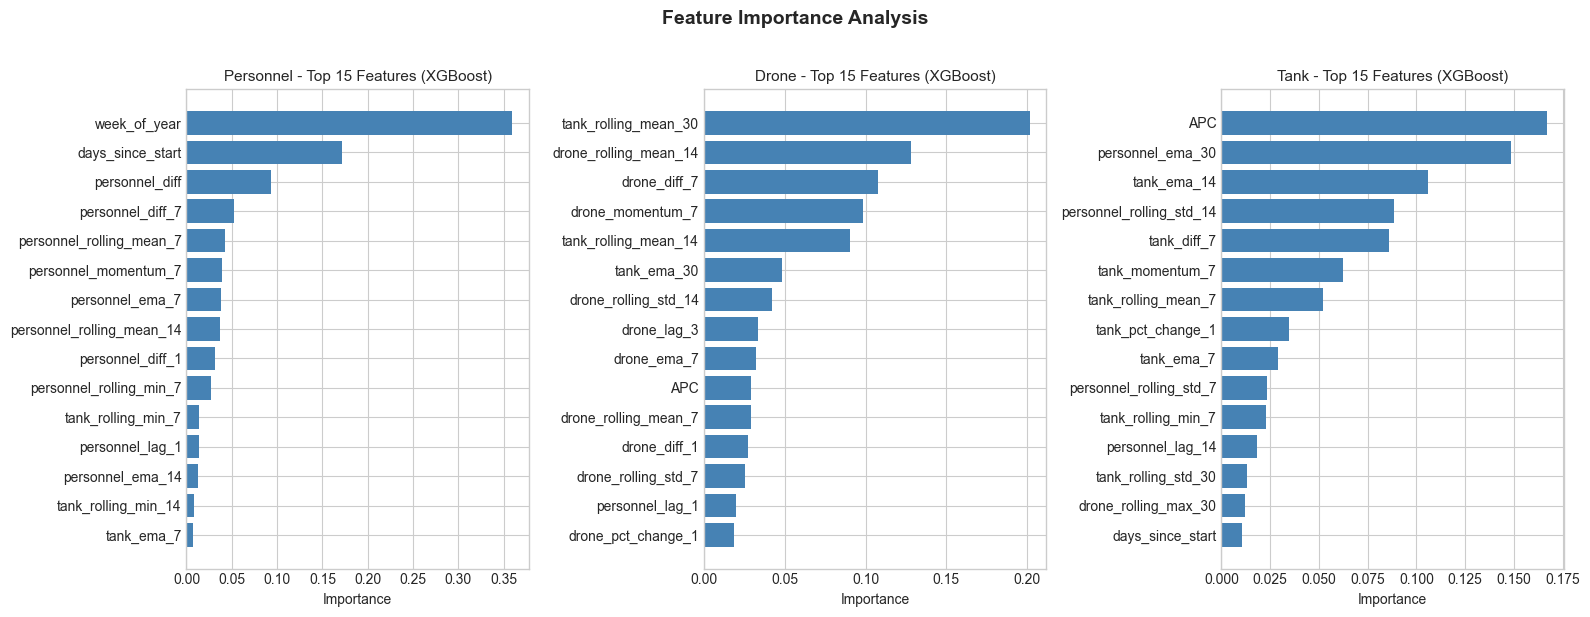

In [42]:
# =============================================================================
# 7.4 Feature Importance Analysis
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for idx, target in enumerate(TARGET_COLS):
    # Get feature importance from XGBoost
    importance = xgb_models[target].feature_importances_
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': importance
    }).sort_values('importance', ascending=True).tail(15)
    
    axes[idx].barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
    axes[idx].set_xlabel('Importance')
    axes[idx].set_title(f'{target.capitalize()} - Top 15 Features (XGBoost)', fontsize=11)

plt.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [43]:
# =============================================================================
# Phase 8: Deep Learning Models
# =============================================================================
# 8.1 Prepare Data for LSTM/GRU (Sequence Format)
# =============================================================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Sequence length (look-back period)
SEQUENCE_LENGTH = 14

def create_sequences(X, y, seq_length):
    """Create sequences for LSTM/GRU input."""
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i + seq_length])
        y_seq.append(y[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

# Create sequences for each target
lstm_data = {}

for target in TARGET_COLS:
    # Combine train and val for creating sequences (will split later)
    X_combined = np.vstack([X_train_scaled, X_val_scaled])
    y_combined = np.concatenate([y_train_scaled[target], y_val_scaled[target]])
    
    # Create sequences
    X_seq, y_seq = create_sequences(X_combined, y_combined, SEQUENCE_LENGTH)
    
    # Split back into train and validation
    train_len = len(X_train_scaled) - SEQUENCE_LENGTH
    
    lstm_data[target] = {
        'X_train': X_seq[:train_len],
        'y_train': y_seq[:train_len],
        'X_val': X_seq[train_len:],
        'y_val': y_seq[train_len:]
    }
    
print(f"Sequence length: {SEQUENCE_LENGTH}")
print(f"\nLSTM/GRU data shapes:")
for target in TARGET_COLS:
    print(f"  {target}:")
    print(f"    X_train: {lstm_data[target]['X_train'].shape}")
    print(f"    X_val:   {lstm_data[target]['X_val'].shape}")

Sequence length: 14

LSTM/GRU data shapes:
  personnel:
    X_train: (142, 14, 96)
    X_val:   (19, 14, 96)
  drone:
    X_train: (142, 14, 96)
    X_val:   (19, 14, 96)
  tank:
    X_train: (142, 14, 96)
    X_val:   (19, 14, 96)


In [44]:
# =============================================================================
# 8.2 LSTM Model
# =============================================================================

print("=" * 60)
print("LSTM MODEL")
print("=" * 60)

lstm_predictions = {}
lstm_models = {}
lstm_histories = {}

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=0
)

for target in TARGET_COLS:
    print(f"\nTraining LSTM for {target.upper()}...")
    
    n_features = lstm_data[target]['X_train'].shape[2]
    
    model = Sequential([
        LSTM(64, activation='relu', input_shape=(SEQUENCE_LENGTH, n_features), return_sequences=True),
        Dropout(0.2),
        LSTM(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    history = model.fit(
        lstm_data[target]['X_train'],
        lstm_data[target]['y_train'],
        epochs=50,
        batch_size=32,
        validation_data=(lstm_data[target]['X_val'], lstm_data[target]['y_val']),
        callbacks=[early_stopping],
        verbose=0
    )
    
    lstm_models[target] = model
    lstm_histories[target] = history
    
    # Prepare test data sequences
    X_test_combined = np.vstack([X_val_scaled[-SEQUENCE_LENGTH:], X_test_scaled])
    y_test_combined = np.concatenate([y_val_scaled[target][-SEQUENCE_LENGTH:], y_test_scaled[target]])
    X_test_seq, y_test_seq = create_sequences(X_test_combined, y_test_combined, SEQUENCE_LENGTH)
    
    # Predictions (scaled)
    pred_scaled = model.predict(X_test_seq, verbose=0).flatten()
    
    # Inverse transform predictions
    pred = scalers_y[target].inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    y_true = scalers_y[target].inverse_transform(y_test_seq.reshape(-1, 1)).flatten()
    
    lstm_predictions[target] = pred
    
    # Calculate metrics
    metrics = calculate_metrics(y_true, pred, "LSTM")
    all_results[target].append(metrics)
    
    print(f"  Epochs trained: {len(history.history['loss'])}")
    print(f"  MAE:  {metrics['MAE']:.2f}")
    print(f"  RMSE: {metrics['RMSE']:.2f}")
    print(f"  R2:   {metrics['R2']:.4f}")

LSTM MODEL

Training LSTM for PERSONNEL...
  Epochs trained: 17
  MAE:  5507.27
  RMSE: 15275.29
  R2:   -11574.8962

Training LSTM for DRONE...
  Epochs trained: 10
  MAE:  348.82
  RMSE: 596.70
  R2:   -2122.7644

Training LSTM for TANK...
  Epochs trained: 10
  MAE:  507.86
  RMSE: 796.60
  R2:   -74943.9671


In [45]:
# =============================================================================
# 8.3 GRU Model
# =============================================================================

print("=" * 60)
print("GRU MODEL")
print("=" * 60)

gru_predictions = {}
gru_models = {}
gru_histories = {}

for target in TARGET_COLS:
    print(f"\nTraining GRU for {target.upper()}...")
    
    n_features = lstm_data[target]['X_train'].shape[2]
    
    model = Sequential([
        GRU(64, activation='relu', input_shape=(SEQUENCE_LENGTH, n_features), return_sequences=True),
        Dropout(0.2),
        GRU(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    history = model.fit(
        lstm_data[target]['X_train'],
        lstm_data[target]['y_train'],
        epochs=50,
        batch_size=32,
        validation_data=(lstm_data[target]['X_val'], lstm_data[target]['y_val']),
        callbacks=[early_stopping],
        verbose=0
    )
    
    gru_models[target] = model
    gru_histories[target] = history
    
    # Prepare test data sequences
    X_test_combined = np.vstack([X_val_scaled[-SEQUENCE_LENGTH:], X_test_scaled])
    y_test_combined = np.concatenate([y_val_scaled[target][-SEQUENCE_LENGTH:], y_test_scaled[target]])
    X_test_seq, y_test_seq = create_sequences(X_test_combined, y_test_combined, SEQUENCE_LENGTH)
    
    # Predictions (scaled)
    pred_scaled = model.predict(X_test_seq, verbose=0).flatten()
    
    # Inverse transform predictions
    pred = scalers_y[target].inverse_transform(pred_scaled.reshape(-1, 1)).flatten()
    y_true = scalers_y[target].inverse_transform(y_test_seq.reshape(-1, 1)).flatten()
    
    gru_predictions[target] = pred
    
    # Calculate metrics
    metrics = calculate_metrics(y_true, pred, "GRU")
    all_results[target].append(metrics)
    
    print(f"  Epochs trained: {len(history.history['loss'])}")
    print(f"  MAE:  {metrics['MAE']:.2f}")
    print(f"  RMSE: {metrics['RMSE']:.2f}")
    print(f"  R2:   {metrics['R2']:.4f}")

GRU MODEL

Training GRU for PERSONNEL...
  Epochs trained: 21
  MAE:  2135.27
  RMSE: 2390.56
  R2:   -282.5145

Training GRU for DRONE...
  Epochs trained: 10
  MAE:  115.26
  RMSE: 226.44
  R2:   -304.8521

Training GRU for TANK...
  Epochs trained: 10
  MAE:  151.14
  RMSE: 232.19
  R2:   -6366.0028


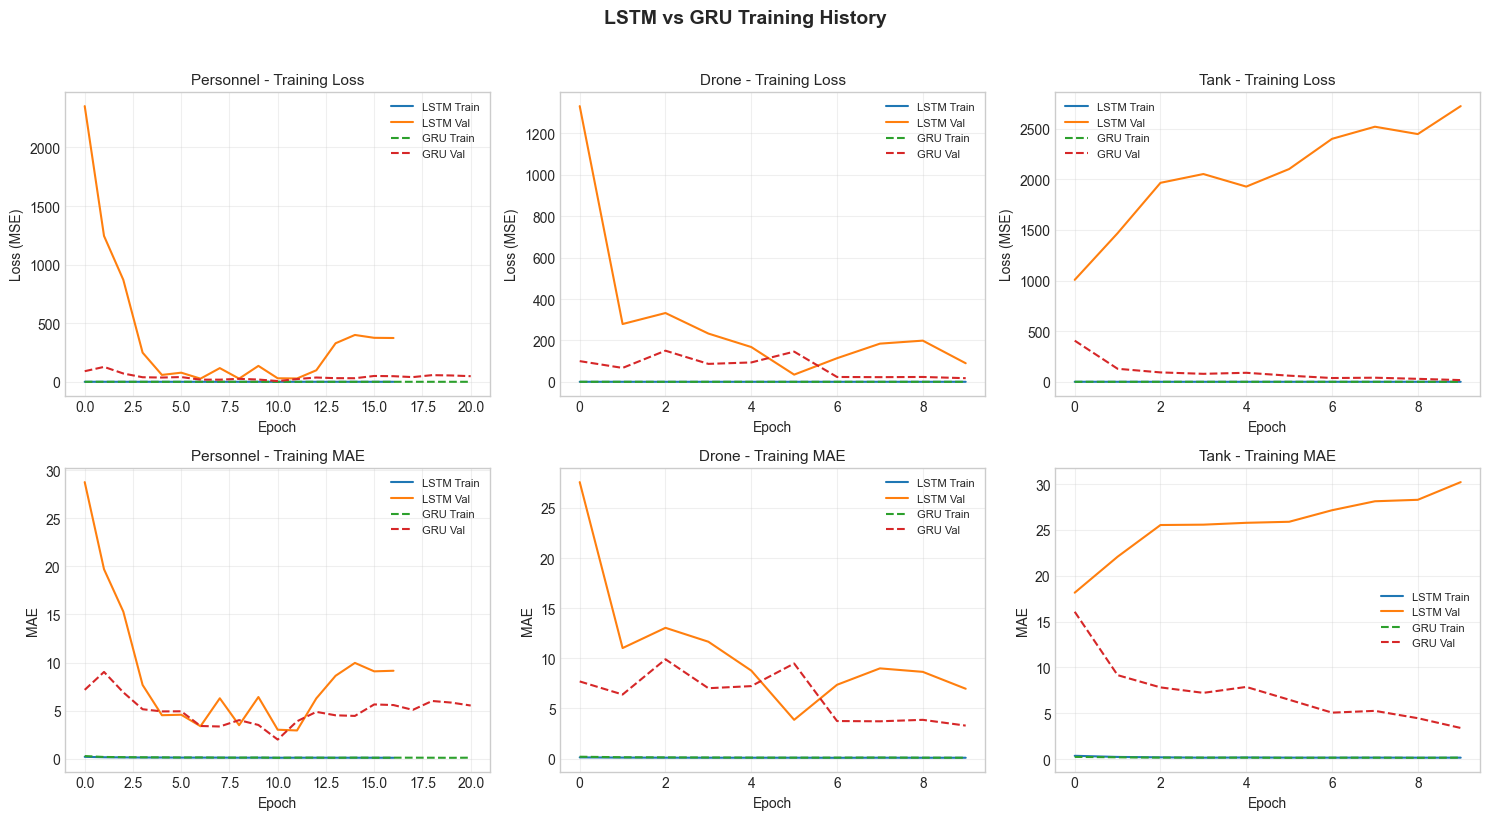

In [46]:
# =============================================================================
# 8.4 Training History Visualization
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, target in enumerate(TARGET_COLS):
    # Loss plot
    axes[0, idx].plot(lstm_histories[target].history['loss'], label='LSTM Train')
    axes[0, idx].plot(lstm_histories[target].history['val_loss'], label='LSTM Val')
    axes[0, idx].plot(gru_histories[target].history['loss'], label='GRU Train', linestyle='--')
    axes[0, idx].plot(gru_histories[target].history['val_loss'], label='GRU Val', linestyle='--')
    axes[0, idx].set_title(f'{target.capitalize()} - Training Loss', fontsize=11)
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Loss (MSE)')
    axes[0, idx].legend(fontsize=8)
    axes[0, idx].grid(True, alpha=0.3)
    
    # MAE plot
    axes[1, idx].plot(lstm_histories[target].history['mae'], label='LSTM Train')
    axes[1, idx].plot(lstm_histories[target].history['val_mae'], label='LSTM Val')
    axes[1, idx].plot(gru_histories[target].history['mae'], label='GRU Train', linestyle='--')
    axes[1, idx].plot(gru_histories[target].history['val_mae'], label='GRU Val', linestyle='--')
    axes[1, idx].set_title(f'{target.capitalize()} - Training MAE', fontsize=11)
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('MAE')
    axes[1, idx].legend(fontsize=8)
    axes[1, idx].grid(True, alpha=0.3)

plt.suptitle('LSTM vs GRU Training History', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [47]:
# =============================================================================
# Phase 9: Model Comparison & Evaluation
# =============================================================================
# 9.1 Results Summary Tables
# =============================================================================

print("=" * 80)
print("MODEL COMPARISON - RESULTS SUMMARY")
print("=" * 80)

for target in TARGET_COLS:
    print(f"\n{'='*60}")
    print(f"TARGET: {target.upper()}")
    print(f"{'='*60}")
    
    results_df = pd.DataFrame(all_results[target])
    results_df = results_df.sort_values('RMSE')
    
    print(results_df.to_string(index=False))
    print(f"\nBest Model (by RMSE): {results_df.iloc[0]['Model']}")

MODEL COMPARISON - RESULTS SUMMARY

TARGET: PERSONNEL
                    Model         MAE          MSE         RMSE        MAPE            R2
Naive (Lag-1) + Mean Diff   70.881720 7.877440e+03    88.754943   12.938966      0.609194
            Naive (Lag-1)   70.952381 7.919048e+03    88.989031   12.952098      0.607130
              EMA (7-day)   75.617123 1.001069e+04   100.053454   14.767012      0.503362
   Moving Average (7-day)   82.585034 1.172303e+04   108.272952   15.943757      0.418411
          XGBoost (Tuned)  165.162368 3.753241e+04   193.732839   27.080722     -0.862012
         LightGBM (Tuned)  167.149457 4.044499e+04   201.109403   27.528153     -1.006507
    Random Forest (Tuned)  188.900637 5.073521e+04   225.244777   29.660822     -1.517012
             ARIMA(1,1,1)  198.792954 5.607153e+04   236.794273   31.328979     -1.781751
   SARIMA(1,1,1)(1,0,1,7)  238.274328 7.680786e+04   277.142311   37.881485     -2.810497
                      GRU 2135.271386 5.714778

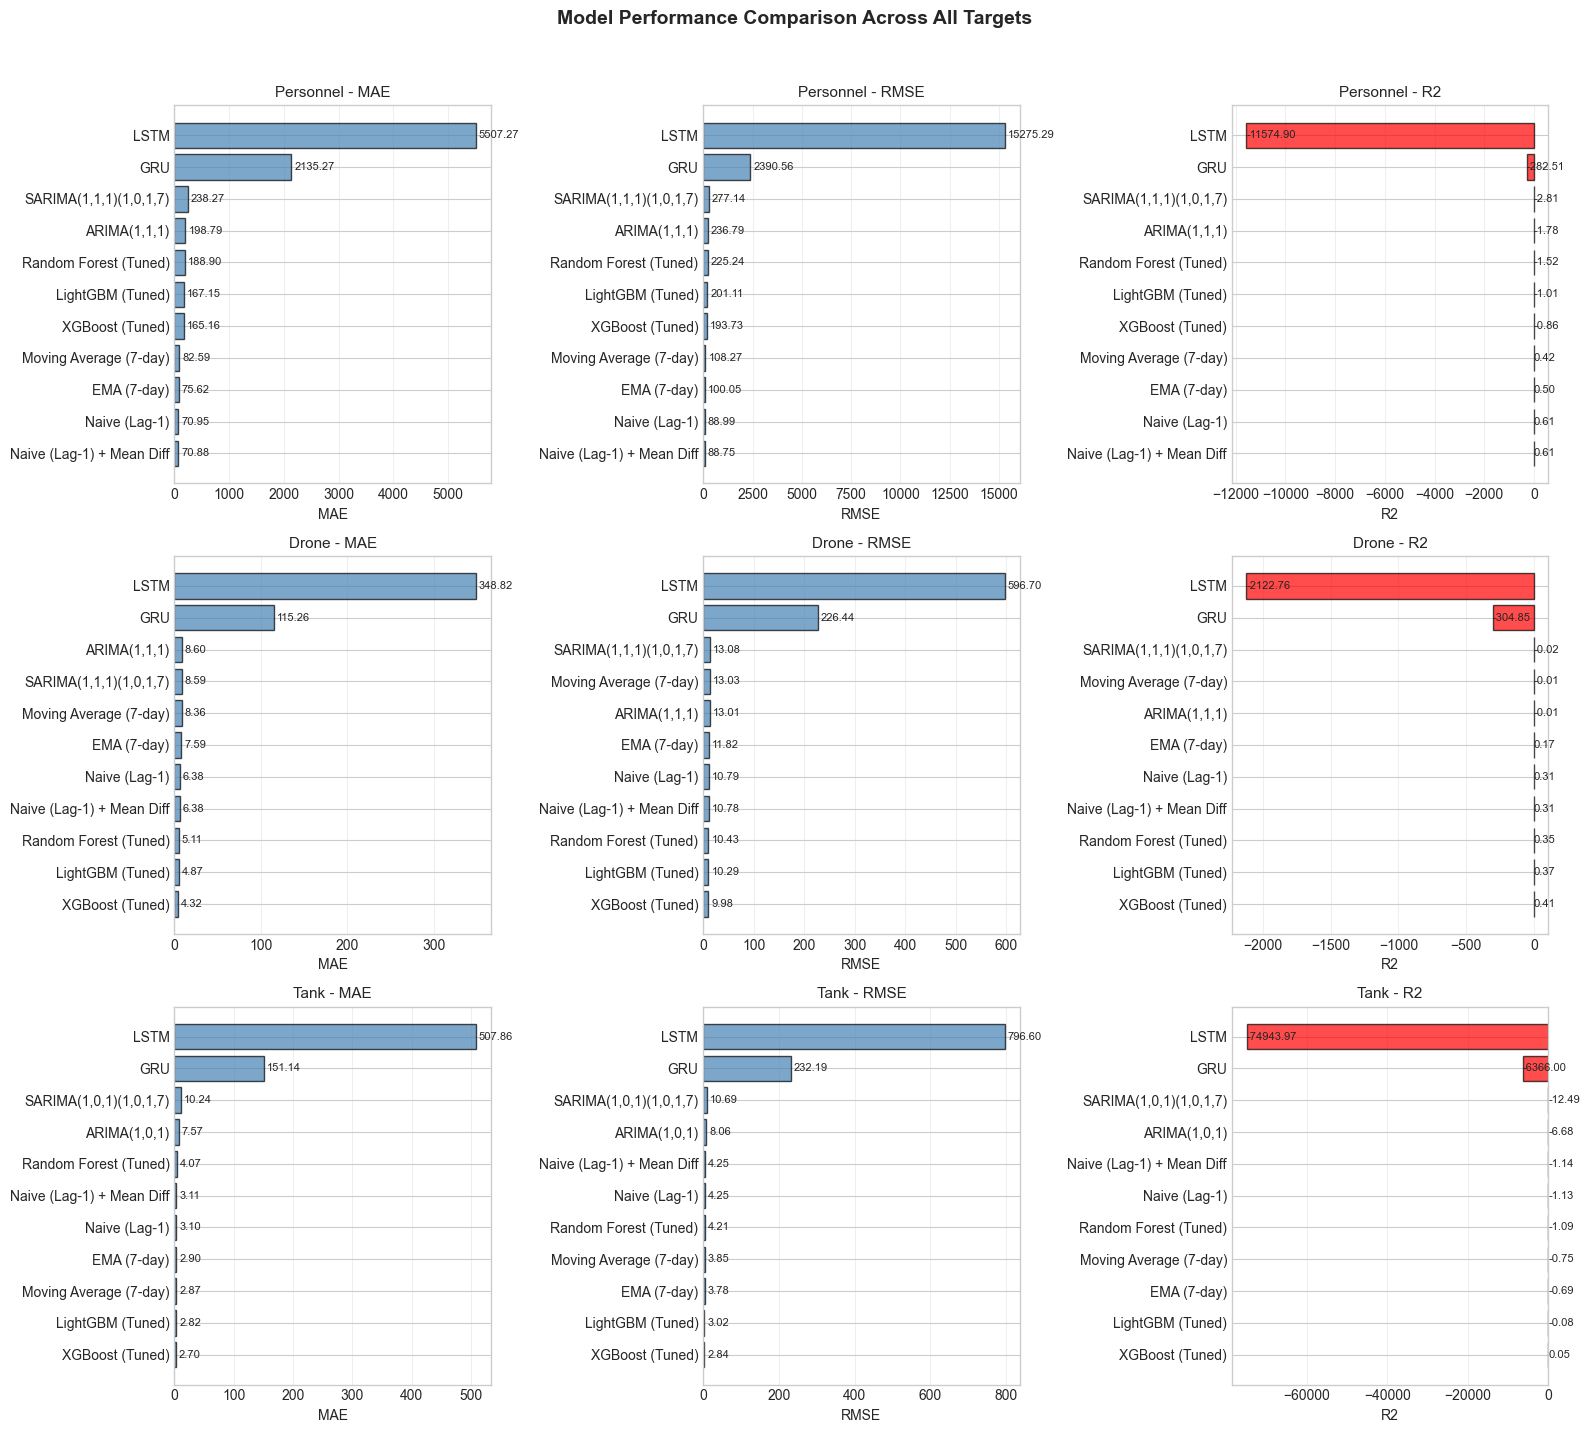

In [48]:
# =============================================================================
# 9.2 Visual Model Comparison (Bar Charts)
# =============================================================================

fig, axes = plt.subplots(3, 3, figsize=(16, 14))

metrics_to_plot = ['MAE', 'RMSE', 'R2']

for row, target in enumerate(TARGET_COLS):
    results_df = pd.DataFrame(all_results[target])
    
    for col, metric in enumerate(metrics_to_plot):
        ax = axes[row, col]
        
        # Sort by the metric for better visualization
        if metric == 'R2':
            sorted_df = results_df.sort_values(metric, ascending=False)
            colors = ['green' if x > 0 else 'red' for x in sorted_df[metric]]
        else:
            sorted_df = results_df.sort_values(metric, ascending=True)
            colors = ['steelblue'] * len(sorted_df)
        
        bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=colors, alpha=0.7, edgecolor='black')
        ax.set_xlabel(metric)
        ax.set_title(f'{target.capitalize()} - {metric}', fontsize=11)
        ax.grid(True, alpha=0.3, axis='x')
        
        # Add value labels
        for bar, val in zip(bars, sorted_df[metric]):
            ax.text(bar.get_width() + 0.01 * max(sorted_df[metric]), bar.get_y() + bar.get_height()/2, 
                   f'{val:.2f}', va='center', fontsize=8)

plt.suptitle('Model Performance Comparison Across All Targets', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [49]:
# =============================================================================
# 9.3 Predictions vs Actuals Visualization (Best Models)
# =============================================================================

# Determine best model for each target
best_models = {}
best_predictions = {}

for target in TARGET_COLS:
    results_df = pd.DataFrame(all_results[target])
    best_model_name = results_df.sort_values('RMSE').iloc[0]['Model']
    best_models[target] = best_model_name
    
    # Get corresponding predictions (handle both tuned and non-tuned names)
    if 'XGBoost' in best_model_name:
        best_predictions[target] = xgb_predictions[target]
    elif 'LightGBM' in best_model_name:
        best_predictions[target] = lgbm_predictions[target]
    elif 'Random Forest' in best_model_name:
        best_predictions[target] = rf_predictions[target]
    elif 'LSTM' in best_model_name:
        best_predictions[target] = lstm_predictions[target]
    elif 'GRU' in best_model_name:
        best_predictions[target] = gru_predictions[target]
    elif 'SARIMA' in best_model_name:
        best_predictions[target] = sarima_predictions[target]
    elif 'ARIMA' in best_model_name:
        best_predictions[target] = arima_predictions[target]
    elif 'EMA' in best_model_name:
        best_predictions[target] = ema_predictions[target]
    elif 'Moving Average' in best_model_name:
        best_predictions[target] = ma_predictions[target]
    else:
        best_predictions[target] = naive_predictions[target]

print("Best models selected (after hyperparameter tuning):")
for target in TARGET_COLS:
    print(f"  {target}: {best_models[target]}")

Best models selected (after hyperparameter tuning):
  personnel: Naive (Lag-1) + Mean Diff
  drone: XGBoost (Tuned)
  tank: XGBoost (Tuned)


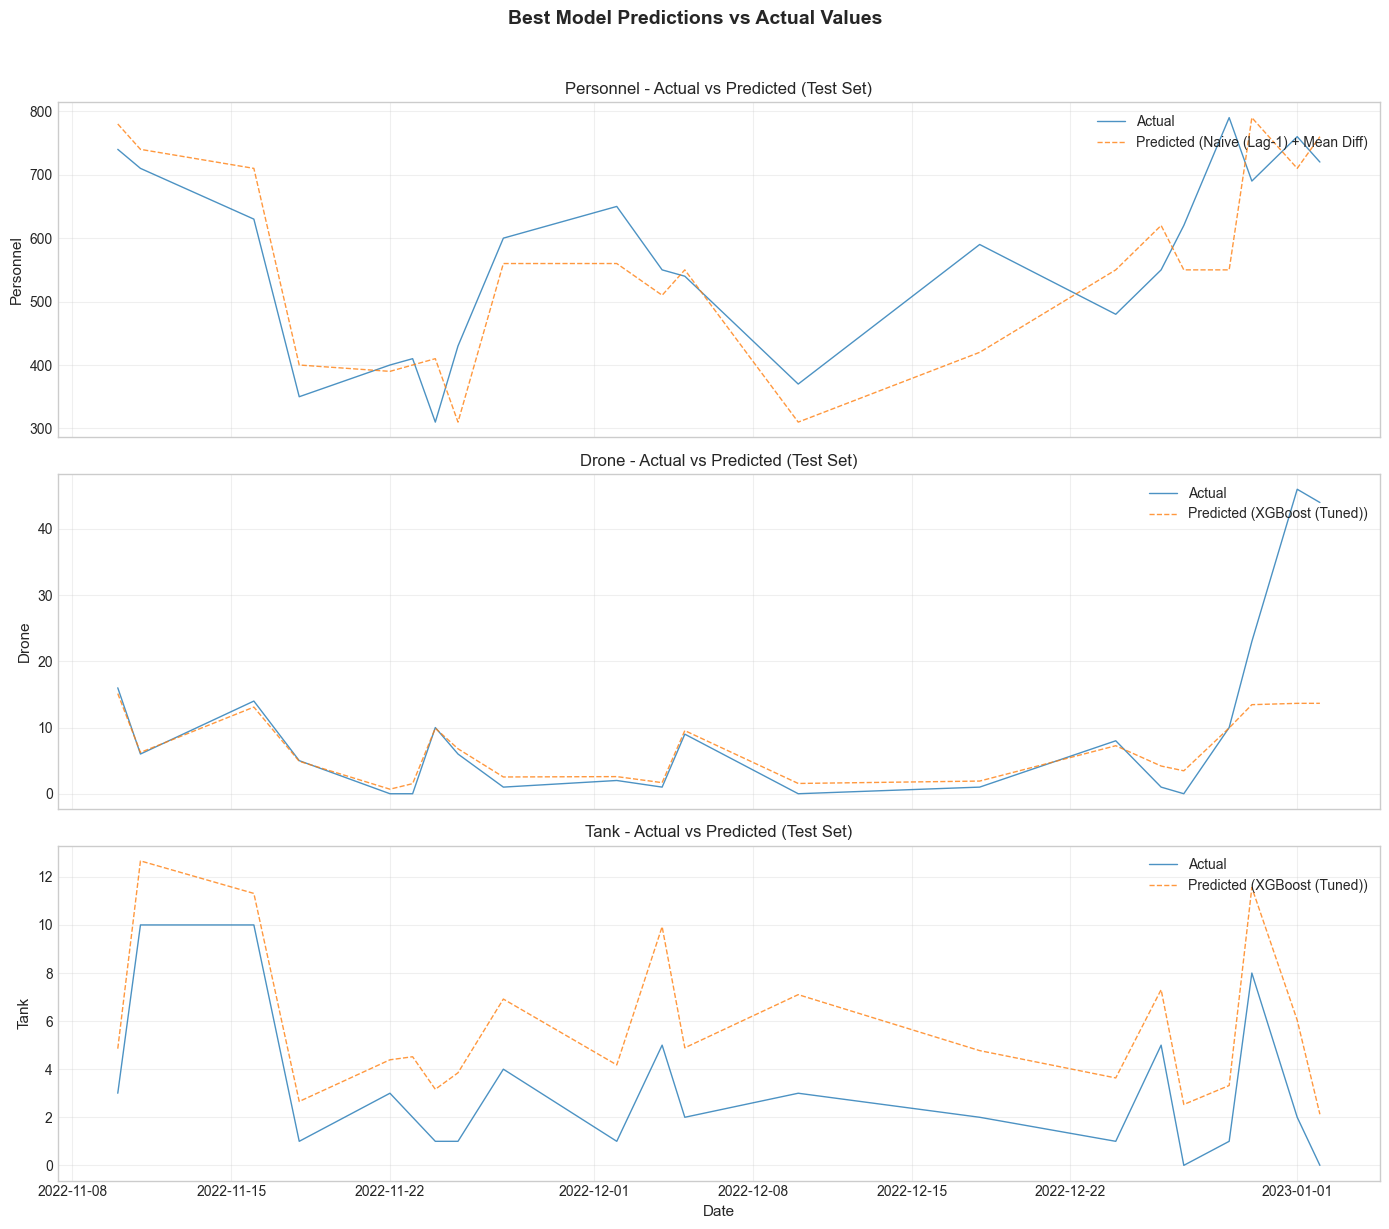

In [50]:
# =============================================================================
# 9.4 Time Series Plot: Actual vs Best Model Predictions
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    
    pred = best_predictions[target]
    actual = y_test[target].values[:len(pred)]
    dates = test_df['date'].values[:len(pred)]
    
    ax.plot(dates, actual, label='Actual', linewidth=1, alpha=0.8)
    ax.plot(dates, pred, label=f'Predicted ({best_models[target]})', linewidth=1, alpha=0.8, linestyle='--')
    
    ax.set_ylabel(target.capitalize(), fontsize=11)
    ax.set_title(f'{target.capitalize()} - Actual vs Predicted (Test Set)', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=11)
plt.suptitle('Best Model Predictions vs Actual Values', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

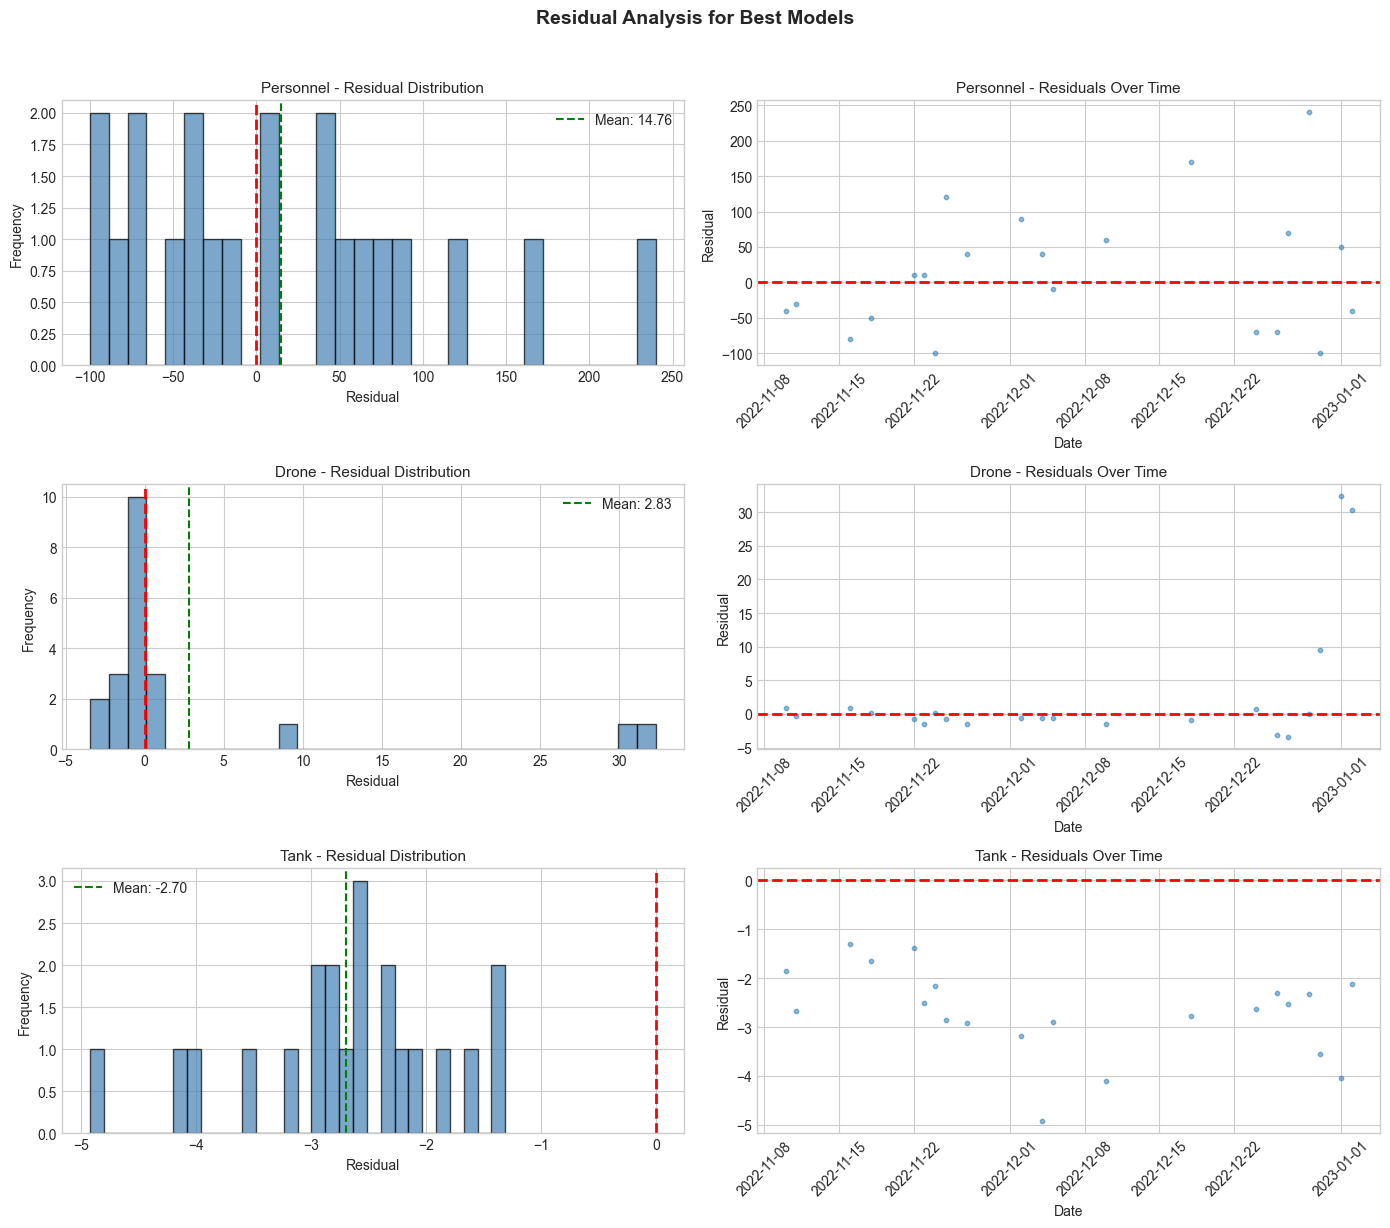

In [51]:
# =============================================================================
# 9.5 Residual Analysis
# =============================================================================

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for idx, target in enumerate(TARGET_COLS):
    pred = best_predictions[target]
    actual = y_test[target].values[:len(pred)]
    residuals = actual - pred
    
    # Residual distribution
    axes[idx, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[idx, 0].axvline(x=np.mean(residuals), color='green', linestyle='--', label=f'Mean: {np.mean(residuals):.2f}')
    axes[idx, 0].set_xlabel('Residual')
    axes[idx, 0].set_ylabel('Frequency')
    axes[idx, 0].set_title(f'{target.capitalize()} - Residual Distribution', fontsize=11)
    axes[idx, 0].legend()
    
    # Residuals over time
    dates = test_df['date'].values[:len(pred)]
    axes[idx, 1].scatter(dates, residuals, alpha=0.5, s=10)
    axes[idx, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[idx, 1].set_xlabel('Date')
    axes[idx, 1].set_ylabel('Residual')
    axes[idx, 1].set_title(f'{target.capitalize()} - Residuals Over Time', fontsize=11)
    axes[idx, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Residual Analysis for Best Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [61]:
# =============================================================================
# Phase 10: Final Predictions & Conclusions
# =============================================================================
# 10.1 Future Predictions (Next 30 Days) - Using Best Models
# =============================================================================

FORECAST_DAYS = 30

print("=" * 60)
print(f"FUTURE PREDICTIONS (Next {FORECAST_DAYS} Days)")
print("=" * 60)

# Get last known data point
last_date = df_clean['date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS, freq='D')

print(f"\nForecast period: {future_dates[0].strftime('%Y-%m-%d')} to {future_dates[-1].strftime('%Y-%m-%d')}")

# Determine best model for each target based on test set RMSE
future_predictions = {}
best_models_for_forecast = {}

for target in TARGET_COLS:
    results_df = pd.DataFrame(all_results[target])
    best_row = results_df.sort_values('RMSE').iloc[0]
    best_model_name = best_row['Model']
    best_models_for_forecast[target] = best_model_name
    
    print(f"\n{target.upper()}:")
    print(f"  Best Model: {best_model_name} (Test RMSE: {best_row['RMSE']:.2f})")
    
    d = differencing_order[target]
    
    # For ARIMA/SARIMA models - they have built-in forecasting
    if 'ARIMA' in best_model_name or 'SARIMA' in best_model_name:
        if 'SARIMA' in best_model_name and target in sarima_models:
            forecast = sarima_models[target].forecast(steps=FORECAST_DAYS)
        elif target in arima_models:
            forecast = arima_models[target].forecast(steps=FORECAST_DAYS)
        future_predictions[target] = np.maximum(forecast.values, 0)
        
    # For ML models - need to do recursive forecasting
    elif any(name in best_model_name for name in ['XGBoost', 'LightGBM', 'Random Forest']):
        # Get the appropriate model
        if 'XGBoost' in best_model_name:
            model = xgb_models[target]
        elif 'LightGBM' in best_model_name:
            model = lgbm_models[target]
        else:
            model = rf_models[target]
        
        # Recursive multi-step forecasting
        last_features = df_clean[feature_cols].iloc[-1:].copy()
        last_target_value = df_clean[target].iloc[-1]
        
        predictions = []
        current_features = last_features.values.flatten()
        prev_value = last_target_value
        
        for step in range(FORECAST_DAYS):
            pred_stationary = model.predict(current_features.reshape(1, -1))[0]
            
            if d > 0:
                pred_original = pred_stationary + prev_value
            else:
                pred_original = pred_stationary
            
            predictions.append(max(pred_original, 0))
            prev_value = pred_original
            
            # Update lag_1 feature if it exists
            lag_1_col = f'{target}_lag_1'
            if lag_1_col in feature_cols:
                lag_1_idx = feature_cols.index(lag_1_col)
                current_features[lag_1_idx] = pred_original
        
        future_predictions[target] = np.array(predictions)
    
    # For LSTM/GRU - use recursive forecasting with sequences
    elif 'LSTM' in best_model_name or 'GRU' in best_model_name:
        if 'LSTM' in best_model_name:
            model = lstm_models[target]
        else:
            model = gru_models[target]
        
        # Get last sequence
        last_seq = X_test_scaled[-SEQUENCE_LENGTH:].copy()
        last_target_value = df_clean[target].iloc[-1]
        
        predictions = []
        current_seq = last_seq.copy()
        prev_value = last_target_value
        
        for step in range(FORECAST_DAYS):
            pred_scaled = model.predict(current_seq.reshape(1, SEQUENCE_LENGTH, -1), verbose=0)[0, 0]
            pred_stationary = scalers_y[target].inverse_transform([[pred_scaled]])[0, 0]
            
            if d > 0:
                pred_original = pred_stationary + prev_value
            else:
                pred_original = pred_stationary
            
            predictions.append(max(pred_original, 0))
            prev_value = pred_original
            
            # Shift sequence and add new prediction (simplified)
            current_seq = np.roll(current_seq, -1, axis=0)
        
        future_predictions[target] = np.array(predictions)
    
    # For Naive/EMA/MA baseline models - recursive with simple logic
    elif 'Naive' in best_model_name or 'EMA' in best_model_name or 'Moving Average' in best_model_name:
        # --------------------------------------------
        # Naive (Lag-1) + Mean Diff
        # --------------------------------------------
        if 'Naive (Lag-1) + Mean Diff' in best_model_name:
            predictions = []

            # Use EXACT same mean_diff as evaluation
            mean_diff = train_df[target].diff().mean()

            # Start from last known actual value
            prev_value = df_clean[target].iloc[-1]

            for step in range(FORECAST_DAYS):
                pred = prev_value + mean_diff
                predictions.append(max(pred, 0))
                prev_value = pred

            future_predictions[target] = np.array(predictions)
            continue  # Skip other baseline logic

        # --------------------------------------------
        # Pure Naive (Last Value)
        # --------------------------------------------
        if best_model_name == 'Naive (Last Value)':
            last_val = df_clean[target].iloc[-1]
            future_predictions[target] = np.full(FORECAST_DAYS, last_val)
            continue

        # --------------------------------------------
        # EMA baseline
        # --------------------------------------------
        if 'EMA' in best_model_name:
            predictions = []
            last_ema = df_clean[f'{target}_ema_7'].iloc[-1]
            mean_val = df_clean[target].mean()
            alpha = 0.1
            prev = last_ema
            for step in range(FORECAST_DAYS):
                pred = prev * (1 - alpha) + mean_val * alpha
                predictions.append(max(pred, 0))
                prev = pred
            future_predictions[target] = np.array(predictions)
            continue

        # --------------------------------------------
        # Moving Average baseline
        # --------------------------------------------
        if 'Moving Average' in best_model_name:
            predictions = []
            last_ma = df_clean[f'{target}_rolling_mean_7'].iloc[-1]
            mean_val = df_clean[target].mean()
            alpha = 0.05
            prev = last_ma
            for step in range(FORECAST_DAYS):
                pred = prev * (1 - alpha) + mean_val * alpha
                predictions.append(max(pred, 0))
                prev = pred
            future_predictions[target] = np.array(predictions)
            continue
    
    else:
        # Fallback: use last 7-day average
        last_7_avg = df_clean[target].tail(7).mean()
        future_predictions[target] = np.full(FORECAST_DAYS, last_7_avg)
    
    print(f"  Predicted total for next {FORECAST_DAYS} days: {future_predictions[target].sum():.0f}")
    print(f"  Daily average: {future_predictions[target].mean():.1f}")
    print(f"  Min: {future_predictions[target].min():.1f}, Max: {future_predictions[target].max():.1f}")

FUTURE PREDICTIONS (Next 30 Days)

Forecast period: 2023-01-03 to 2023-02-01

PERSONNEL:
  Best Model: Naive (Lag-1) + Mean Diff (Test RMSE: 88.75)

DRONE:
  Best Model: XGBoost (Tuned) (Test RMSE: 9.98)
  Predicted total for next 30 days: 7672
  Daily average: 255.7
  Min: 57.7, Max: 453.8

TANK:
  Best Model: XGBoost (Tuned) (Test RMSE: 2.84)
  Predicted total for next 30 days: 64
  Daily average: 2.1
  Min: 2.1, Max: 2.1


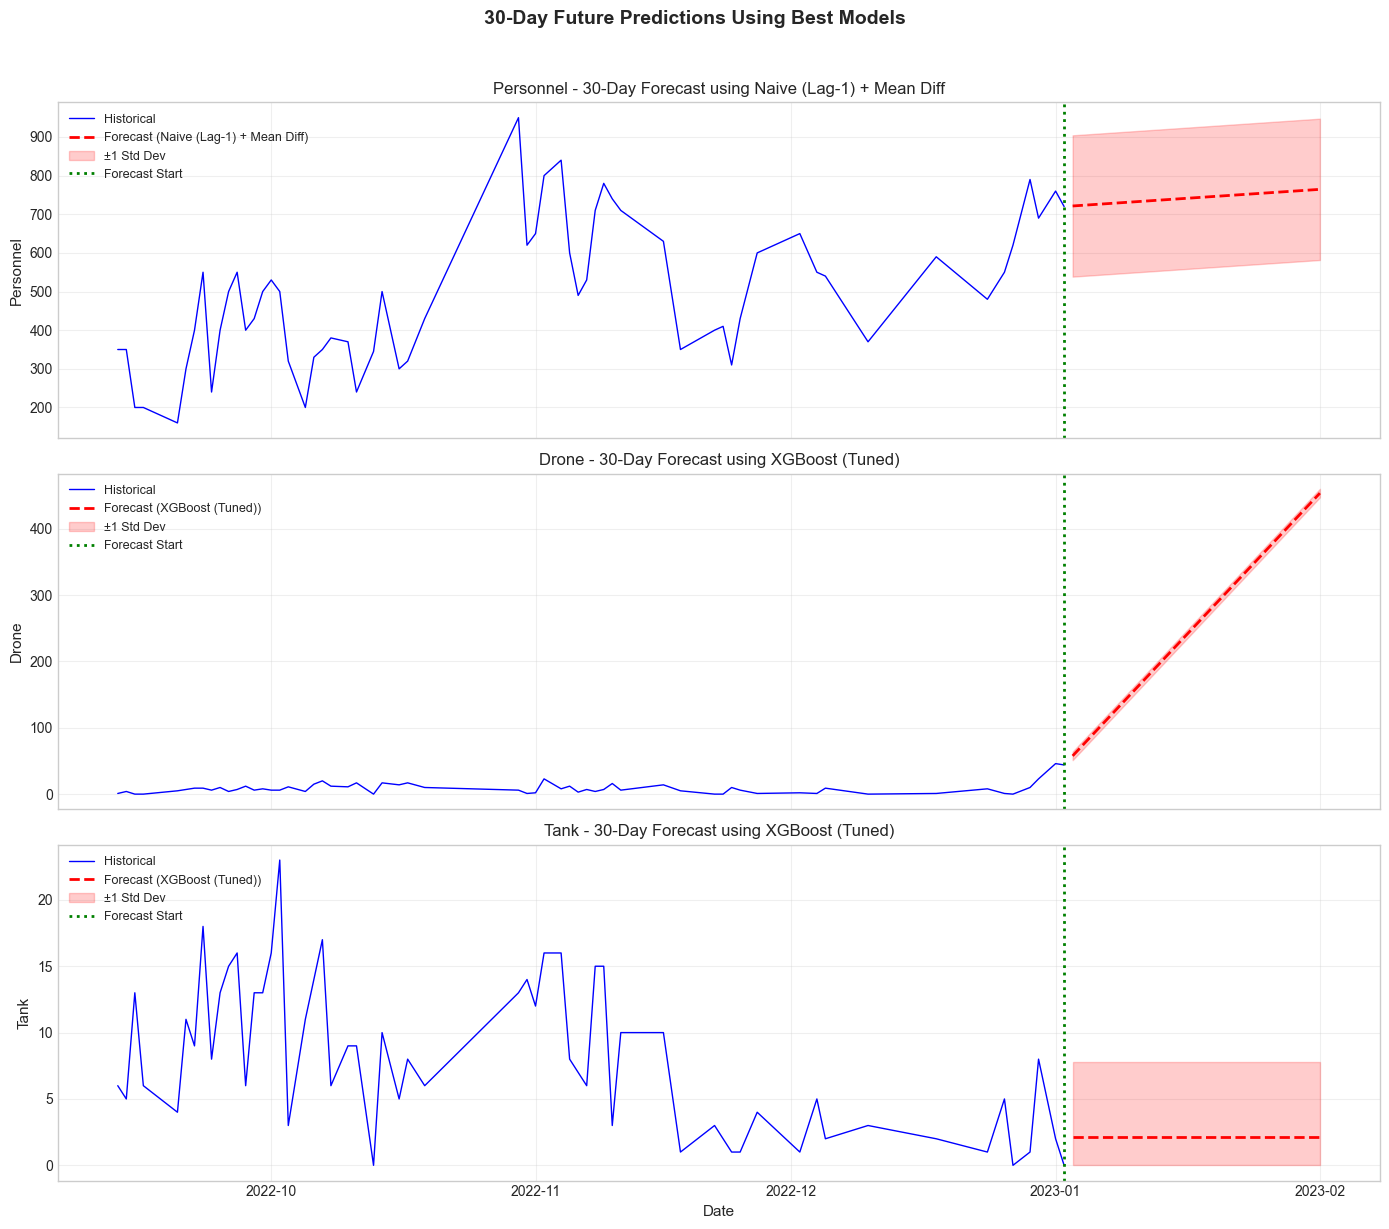

In [62]:
# =============================================================================
# 10.2 Future Predictions Visualization
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Get last 60 days of actual data for context
context_days = 60

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    
    # Historical data (last 60 days)
    historical_dates = df_clean['date'].tail(context_days)
    historical_values = df_clean[target].tail(context_days)
    
    # Plot historical
    ax.plot(historical_dates, historical_values, label='Historical', linewidth=1, color='blue')
    
    # Plot predictions with best model name
    best_model = best_models_for_forecast[target]
    ax.plot(future_dates, future_predictions[target], 
            label=f'Forecast ({best_model})', 
            linewidth=2, color='red', linestyle='--')
    
    # Add confidence band (simple ±1 std approach)
    std = df_clean[target].std()
    ax.fill_between(future_dates, 
                   np.maximum(future_predictions[target] - std, 0),
                   future_predictions[target] + std,
                   alpha=0.2, color='red', label='±1 Std Dev')
    
    # Vertical line for forecast start
    ax.axvline(x=last_date, color='green', linestyle=':', linewidth=2, label='Forecast Start')
    
    ax.set_ylabel(target.capitalize(), fontsize=11)
    ax.set_title(f'{target.capitalize()} - 30-Day Forecast using {best_model}', fontsize=12)
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date', fontsize=11)
plt.suptitle(f'30-Day Future Predictions Using Best Models', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [57]:
# =============================================================================
# 10.3 Forecast Summary Table
# =============================================================================

forecast_summary = pd.DataFrame({
    'Target': TARGET_COLS,
    'Best Model': [best_models_for_forecast[t] for t in TARGET_COLS],
    'Test RMSE': [pd.DataFrame(all_results[t]).sort_values('RMSE').iloc[0]['RMSE'] for t in TARGET_COLS],
    'Total Next 30 Days': [future_predictions[t].sum() for t in TARGET_COLS],
    'Daily Average': [future_predictions[t].mean() for t in TARGET_COLS],
    'Daily Min': [future_predictions[t].min() for t in TARGET_COLS],
    'Daily Max': [future_predictions[t].max() for t in TARGET_COLS],
    'Historical Daily Avg': [df_clean[t].mean() for t in TARGET_COLS]
})

forecast_summary['Test RMSE'] = forecast_summary['Test RMSE'].round(2)
forecast_summary['Total Next 30 Days'] = forecast_summary['Total Next 30 Days'].round(0).astype(int)
forecast_summary['Daily Average'] = forecast_summary['Daily Average'].round(1)
forecast_summary['Daily Min'] = forecast_summary['Daily Min'].round(1)
forecast_summary['Daily Max'] = forecast_summary['Daily Max'].round(1)
forecast_summary['Historical Daily Avg'] = forecast_summary['Historical Daily Avg'].round(1)

print("=" * 80)
print("30-DAY FORECAST SUMMARY (Using Best Models)")
print("=" * 80)
print(forecast_summary.to_string(index=False))

30-DAY FORECAST SUMMARY (Using Best Models)
   Target                Best Model  Test RMSE  Total Next 30 Days  Daily Average  Daily Min  Daily Max  Historical Daily Avg
personnel Naive (Lag-1) + Mean Diff      88.75               19757          658.6      658.6      658.6                 301.6
    drone           XGBoost (Tuned)       9.98                7672          255.7       57.7      453.8                   6.2
     tank           XGBoost (Tuned)       2.84                  64            2.1        2.1        2.1                   8.3
